# Прелюдия
Внутри Т-Банка в разделе «Путешествия» пользователи могут приобретать билеты
на самолеты и бронировать отели. Датасет содержит информацию о покупках клиентами номеров в отелях, включая детали о тех, кто забронировал номер с применением промокодов или кэшбэка. Также в датасет включены характеристики пользователей, которые могут помочь в дальнейшем анализе их поведения и факторов, влияющих на принятие решения о покупке.

Source: https://dano.hse.ru/data2024

## Описание полей датасета
Часть полей датасета была вырезана в процессе работы ввиду их ненадобности для исследования


* order_online_payment_flg – Флаг онлайн-оплаты
* account_rk – Идентификатор счета
* client_rk –Идентификатор клиента
* order_rk Идентификатор заказа
* loyalty_program_type_nm – All Airlines / Black
* bundle_nm Подписка, применившаяся к оплате (Pro/Premium)
* order_type_cd Продукт: Авиа/Отели
* order_status_cd Статус заказа (расшифровка внизу)
* party_first_order_dt Дата первого заказа у клиента
* party_first_order_type_dt Первый заказ в Авиа или Отелях у клиента (см. order_type_cd)
* free_cancel_booking_dttm Дата, до которой можно бесплатно отменить заказ
* created_dttm Дата создания заказа
* cancel_dttm Дата отмены заказа
* book_start_dttm Дата заезда (для отелей)
* local_book_start_dttm Дата заезда в местном часовом поясе (для отелей)
* book_end_dttm Дата выезда (для отелей)
* hotel_country Страна отеля
* hotel_city Город отеля
* avia_dep_city Город вылета для заказов авиабилетов
* avia_arr_city Город прилета для заказов авиабилетов
* promo_code_discount_amt Размер скидки по промокоду
* loyalty_accrual_rub_amt Начисление баллов лояльности (выгоды)
* nominal_price_eur_amt Сумма заказа в евро
* nominal_price_rub_amt Сумма заказа в рублях
* order_item_cnt Количество позиций в заказе
* month_beginning_balance_rub Баланс в рублях на начало месяца, в котором была совершена покупка
* monthly_income_amt Месячный доход
* suppress_email_flg Отказ от коммуникаций по почте
* suppress_call_flg Отказ от коммуникаций по телефону
* bounce_cd Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
* last_sms_success_flg Было ли последнее СМС успешным
* call_contact_6m_flg Был контакт по телефону в последние 6 месяцев
* call_contact_3m_flg Был контакт по телефону в последние 3 месяца
* call_contact_1m_flg Был контакт по телефону в последний 1 месяц
* good_email_address_flg Флаг хорошего текущего email-адреса
* bad_email_address_flg Флаг плохого текущего email-адреса
* email_valid_flg Флаг валидности имейла
* children_cnt Число детей у клиента
* age Возраст клиента
* age_type_cd Возрастная группа клиента (когорты по 20 лет)
* parent_meeting_region_nm В каком регионе клиент получал карту
* delivery_region_category_cd Тип населенного пункта, в котором получалась карта
* lvn_city_nm Город проживания
* lvn_state_nm Регион проживания
* time_zone_delta_tm Разница часового пояса с Гринвичем
* time_zone_cd Код часового пояса
* last_used_product_cd Последний использованный продукт
* first_used_product_cd Первый использованный продукт
* mobile_phone_operator_nm Оператор мобильной связи
* marital_status_cd Семейный статус человека:
* * IMR — состоит в незарегистрированном браке
* * MAR — женат/замужем
* * DLW — не проживает с супругом(ой)
* * OMR — состоит в зарегистрированном браке
* * CIV — гражданский брак
* * UNM — холост/не замужем
* * DIV — оазведен(а)
* * FAL — никогда не состоял(а) в браке
* * WID — Вдовец/вдова
* education_level_cd Уровень образования клиента:
* * SCH — начальное, среднее
* * GRD — высшее
* * UGR — неполное высшее
* * PGR — два высших
* * ACD — ученая степень
* birth_place Место рождения
* gender_cd Пол
* last_sms_dt Дата отправки последнего СМС
* last_email_send_dt Дата отправки последнего имейла
* last_session_dttm Дата последней сессии



In [ ]:
import pandas as pd
import numpy as np
import warnings
import statsmodels.api as sm
from google.colab import files, drive
from scipy.stats import shapiro
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

uplodaded = drive.mount('/content/drive')
file_path = ''

df = pd.read_csv('/content/drive/My Drive/Учебные файлы/dano_dataset_travel.csv', delimiter=';')

Mounted at /content/drive


#Раздел 1. Предварительная обработка данных*

Первичный осмотр и типы данных:
 Загрузите датасет.
 Изучите структуру: количество строк и столбцов, выведите несколько первых строк.
 Проверьте типы данных всех столбцов. Преобразуйте их при необходимости (например, столбец с датой — в тип datetime, CustomerID — в string или category).

Анализ категориальных признаков:
 Выделите категориальные столбцы.
 Для каждого из них посчитайте количество уникальных значений и выведите их список.
 При необходимости выполните преобразования (например, приведите названия категорий к единому регистру, объедините редкие категории в одну "Другое").

Анализ числовых признаков:
 Выделите числовые столбцы.
 Постройте boxplots и гистограммы для выявления выбросов и аномалий.
 Примите решение и обработайте выбросы: либо удалите их (аргументировав), либо замените на медиану/среднее. Например, отрицательное количество товаров — это аномалия.

Обработка пропущенных значений (Missing Values):
 Проверьте датасет на наличие пропусков.
 По каждому столбцу с пропусками примите решение: удалить строки, заменить на моду/медиану/специальное значение (например, "Unknown"). Решение должно быть обосновано.

Поиск и удаление дубликатов:
 Проверьте dataset на наличие полностью повторяющихся строк.
 Полные дубликаты удалите.





####Первичный осмотр и типы данных:

In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

None

In [ ]:
df['party_first_order_dt'] = pd.to_datetime(df['party_first_order_dt'], errors='coerce')
df['party_first_order_type_dt'] = pd.to_datetime(df['party_first_order_type_dt'], errors='coerce')
df['created_dttm'] = pd.to_datetime(df['created_dttm'], errors='coerce')
df['cancel_dttm'] = pd.to_datetime(df['cancel_dttm'], errors='coerce')
df['book_start_dttm'] = pd.to_datetime(df['book_start_dttm'], errors='coerce')
df['local_book_start_dttm'] = pd.to_datetime(df['local_book_start_dttm'], errors='coerce')
df['book_end_dttm'] = pd.to_datetime(df['book_end_dttm'], errors='coerce')
df['last_sms_dt'] = pd.to_datetime(df['last_sms_dt'], errors='coerce')
df['last_email_send_dt'] = pd.to_datetime(df['last_email_send_dt'], errors='coerce')
df['last_session_dttm'] = pd.to_datetime(df['last_session_dttm'], errors='coerce')



In [ ]:
df.drop(labels=['free_cancel_booking_dttm', 'local_book_start_dttm', 'suppress_email_flg', 'suppress_call_flg', 'bounce_cd', \
                'last_sms_success_flg', 'call_contact_6m_flg', 'call_contact_3m_flg', 'call_contact_1m_flg', 'good_email_address_flg', 'bad_email_address_flg', 'email_valid_flg', \
                'time_zone_delta_tm', 'time_zone_cd', 'last_sms_dt', 'last_email_send_dt', 'last_session_dttm','loyalty_program_type_nm', 'cancel_dttm', 'age_type_cd', \
                'parent_meeting_region_nm', 'delivery_region_category_cd', 'lvn_city_nm', 'last_used_product_cd', 'first_used_product_cd', 'birth_place', \
                'hotel_city', 'book_end_dttm', 'hotel_country', 'avia_dep_city', 'avia_arr_city', 'loyalty_accrual_rub_amt', \
                'lvn_state_nm', 'monthly_income_amt', 'month_beginning_balance_rub', 'order_item_cnt', 'book_start_dttm',
                'party_first_order_type_dt', 'order_status_cd'],
        axis=1,
        inplace=True)

In [ ]:
"""
df.drop(labels=['order_status_cd', 'party_first_order_type_dt'],
        axis=1,
        inplace=True)
"""
pass

In [ ]:
df.head(5)

,order_online_payment_flg,account_rk,client_rk,order_rk,bundle_nm,order_type_cd,party_first_order_dt,created_dttm,promo_code_discount_amt,nominal_price_eur_amt,nominal_price_rub_amt,children_cnt,age,mobile_phone_operator_nm,marital_status_cd,education_level_cd,gender_cd
0,"1,0",209c833731e84d21b5b7e673e0fb848749b9e7d29cda64...,f4959ffb27271192727050953ecb27a8a8a38af413f3d8...,fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e63...,Pro,AIR,2019-12-12,2024-11-01 12:39:13.457847,"0,0","142,0","15018,0","0,0","31,0",Тинькофф Мобайл,NaN,NaN,M
1,"1,0",2bbcde706bead3731f2dc8dfbeefb4e12b42ac63e3d8ba...,7025587bc277176246bc44dff396036552a41d5a92d6aa...,98cb83b7748cdf77e43a50f56335a376b51fb767893303...,Premium,HOT,2019-11-21,2024-04-09 21:27:01.394000,NaN,"277,0","27751,0","0,0","39,0",TELE2,MAR,GRD,M
2,"1,0",a82919af3a5a1869f9becdcffa5c7d303d105797ce45b8...,0368b36ccd204d631305233a1f952bc5fb0e3fd9f690fa...,1bfb05606a8b16d48121b9f128889cc1d198c87d223a1b...,Premium,AIR,2023-01-01,2024-01-23 19:27:45.139941,"0,0","79,0","7590,0","0,0","28,0",Скартел,UNM,GRD,M
3,"1,0",9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,1346344779d7bd788d03ec2ad1908daf71c6358aca47f1...,011a98649e7a2be3027ec27c1f0b0cb5dd5d82dda2f482...,Premium,HOT,2023-12-18,2024-10-19 09:58:20.264000,NaN,"73,0","7705,0","0,0","61,0",Билайн,NaN,NaN,M
4,"1,0",3133e7ae6698dcda9754d6a8b449782320260ff1259547...,1a2a4351a96099f9e49bbe2fc7236d41ac63b444176058...,b5e7909d8d7b902e4cdf268ebcbef6820c10b0ed75614b...,Premium,AIR,2019-02-18,2024-02-06 11:50:47.558707,"0,0","85,0","8352,0","0,0","36,0",МегаФон,MAR,GRD,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_online_payment_flg  786885 non-null  object        
 1   account_rk                835938 non-null  object        
 2   client_rk                 835938 non-null  object        
 3   order_rk                  835938 non-null  object        
 4   bundle_nm                 588049 non-null  object        
 5   order_type_cd             786885 non-null  object        
 6   party_first_order_dt      786885 non-null  datetime64[ns]
 7   created_dttm              786885 non-null  datetime64[ns]
 8   promo_code_discount_amt   615900 non-null  object        
 9   nominal_price_eur_amt     786885 non-null  object        
 10  nominal_price_rub_amt     786885 non-null  object        
 11  children_cnt              719699 non-null  object        
 12  ag

####Анализ категориальных признаков:

In [ ]:
df['order_online_payment_flg'].value_counts()


,count
order_online_payment_flg,
"1,0",786885


In [ ]:
df.query('order_online_payment_flg != "1,0"')[['account_rk', 'client_rk', 'party_first_order_dt', 'nominal_price_rub_amt']]

,account_rk,client_rk,party_first_order_dt,nominal_price_rub_amt
59,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,a1730b3f4f3f05e42cd464884cd5f09555ded9dc165942...,NaT,NaN
75,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,2722bf1a77625145d499de36b86c1fba94d64a848e14e7...,NaT,NaN
114,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,4a6203572f9ebd2e0d9b277922d36307f9e24c4834ec32...,NaT,NaN
124,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,a02d4059f939a0696a99d3561ac00bd971d40c545306fa...,NaT,NaN
170,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,3155b0de93154eaa07483c1f3579d8605c0ac38636506c...,NaT,NaN
...,...,...,...,...
835778,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,e12ad5e4224d80bdd7492e8bb0b8bdfaf8cf7089e1aac2...,NaT,NaN
835797,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,bce7e718b7d4f5d6927d495e5896f5152f8da19d411daa...,NaT,NaN
835801,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,ffa91338cc23e3d9ffab53c66e24a9e27c41ff785d3ce7...,NaT,NaN
835809,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,0def0e1a2fa139cd7223aa00e532b885154c9b4fe0e6c0...,NaT,NaN


In [ ]:
df = df[df['order_online_payment_flg'] == "1,0"]

In [ ]:
df['nominal_price_rub_amt'] = pd.to_numeric(df['nominal_price_rub_amt'].str.replace(',', '.'))
df['nominal_price_eur_amt'] = pd.to_numeric(df['nominal_price_eur_amt'].str.replace(',', '.'))
df['order_online_payment_flg'] = pd.to_numeric(df['order_online_payment_flg'].str.replace(',', '.'))
df['promo_code_discount_amt'] = pd.to_numeric(df['promo_code_discount_amt'].str.replace(',', '.'))
#df['loyalty_accrual_rub_amt'] = pd.to_numeric(df['loyalty_accrual_rub_amt'].str.replace(',', '.'))
#df['monthly_income_amt'] = pd.to_numeric(df['monthly_income_amt'].str.replace(',', '.'))
df['age'] = pd.to_numeric(df['age'].str.replace(',', '.'))
#df['order_item_cnt'] = pd.to_numeric(df['order_item_cnt'].str.replace(',', '.'))
df['children_cnt'] = pd.to_numeric(df['children_cnt'].str.replace(',', '.'))

In [ ]:
df['bundle_nm'].value_counts()

,count
bundle_nm,
Premium,292078
Pro,286277
Private,8364
Team Premium,824
Team Select,271
Team Pro,150
Team Private,37
Tinkoff Premium,25
Tinkoff Pro,23


In [ ]:
df['bundle_nm'] = df['bundle_nm'].replace('Tinkoff Pro', 'Pro')
df['bundle_nm'] = df['bundle_nm'].replace('Tinkoff Premium', 'Premium')
df['bundle_nm'] = df['bundle_nm'].replace(['Team Premium','Team Select', \
                                           'Team Pro', 'Team Private'],\
                                           'Team bundle')
df.loc[df['bundle_nm'].isna(), 'bundle_nm'] = "Нет"

df['bundle_nm'].value_counts()

,count
bundle_nm,
Premium,292103
Pro,286300
Нет,198836
Private,8364
Team bundle,1282


In [ ]:
df['order_type_cd'].value_counts()

,count
order_type_cd,
AIR,615337
HOT,171548


In [ ]:
df['promo_code_discount_amt'].value_counts()

,count
promo_code_discount_amt,
0.0,608182
335.0,2608
100.0,2271
201.0,822
670.0,756
...,...
754.0,1
1032.0,1
3042.0,1


In [ ]:
df['gender_cd'].value_counts()

,count
gender_cd,
M,494636
F,282468


In [ ]:
df['education_level_cd'].value_counts()

,count
education_level_cd,
GRD,304394
UGR,59699
SCH,51590
PGR,26637
ACD,8533


In [ ]:
df['children_cnt'].value_counts()

,count
children_cnt,
0.0,651607
1.0,15947
2.0,10891
3.0,2776
4.0,259
5.0,67
6.0,16
8.0,7


In [ ]:
df['mobile_phone_operator_nm'] = df['mobile_phone_operator_nm'].replace('Tele2', 'TELE2')
df['mobile_phone_operator_nm'] = df['mobile_phone_operator_nm'].replace('Megafon', 'МегаФон')
df['mobile_phone_operator_nm'] = df['mobile_phone_operator_nm'].replace('MTS', 'МТС')
df['mobile_phone_operator_nm'] = df['mobile_phone_operator_nm'].replace('Beeline', 'Билайн')
df.loc[df['mobile_phone_operator_nm'].isin(df['mobile_phone_operator_nm'].value_counts().reset_index().head(10)['mobile_phone_operator_nm'].values)==False, 'mobile_phone_operator_nm']='Другое'









In [ ]:
pd.set_option('display.max_rows', 10)
df['mobile_phone_operator_nm'].value_counts()

,count
mobile_phone_operator_nm,
МТС,241906
МегаФон,184670
Билайн,138144
TELE2,94534
Тинькофф Мобайл,74724
...,...
Другое,4605
"ОАО ""Ростелеком""",4171
МГТС,1910


In [ ]:
df['marital_status_cd'].value_counts()

,count
marital_status_cd,
MAR,216886
UNM,208792
CIV,33133
DIV,31993
WID,2082
DLW,14


####1.4 Обработка пропущенных значений

In [ ]:
pd.set_option('display.max_rows', 100)
df.isna().sum()

,0
order_online_payment_flg,0
account_rk,0
client_rk,0
order_rk,0
bundle_nm,0
order_type_cd,0
party_first_order_dt,0
created_dttm,0
promo_code_discount_amt,170985
nominal_price_eur_amt,0


In [ ]:
df = df[df['gender_cd'].notna()]
df.loc[df['marital_status_cd'].isna(), 'marital_status_cd'] = "No data"
df.loc[df['education_level_cd'].isna(), 'education_level_cd'] = "No data"

#### 1.5 Проверка дубликатов

In [ ]:
df.duplicated().value_counts()

,count
False,777104


In [ ]:
pass
#df['revenue_eur'].isna().value_counts()

In [ ]:
pass
#df.groupby('order_type_cd').mean()

####Анализ числовых признаков:

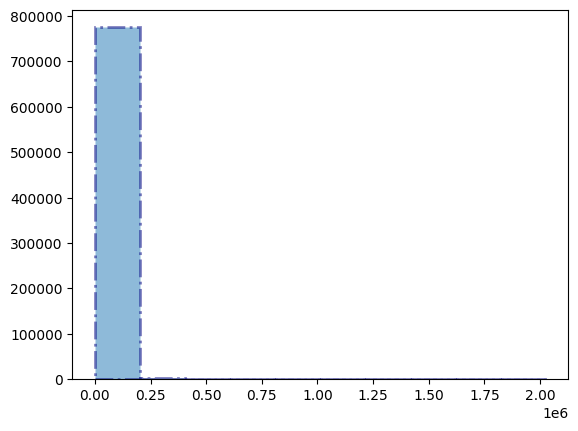

In [ ]:
import matplotlib.pyplot as plt

plt.hist(x = df['nominal_price_rub_amt'],
        bins = 10,
        alpha=0.5,
        linestyle = 'dashdot',
        edgecolor='navy', linewidth = 2,
        histtype = 'bar',
        #range=(0, 15000)
        )
plt.show()

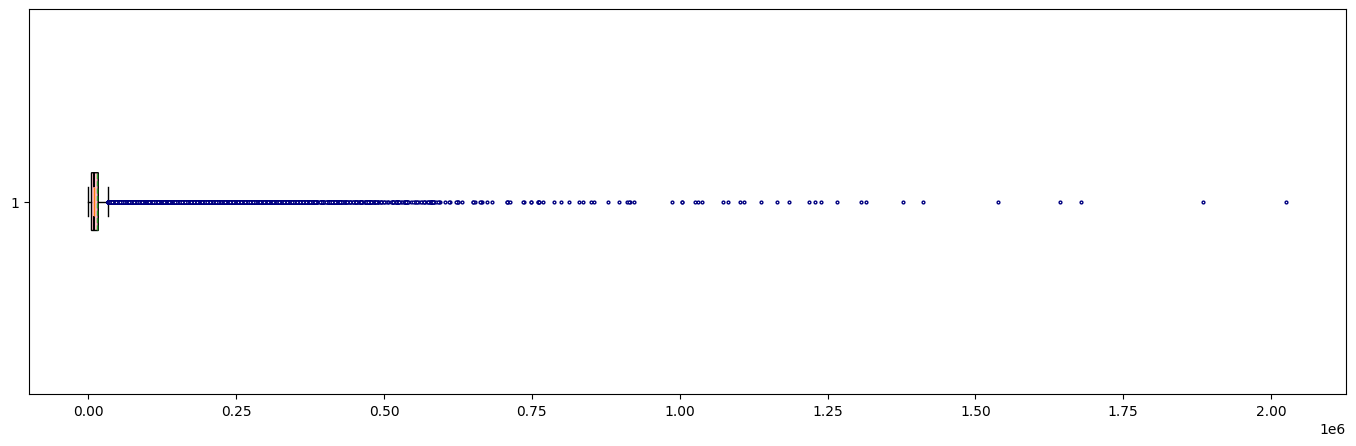

In [ ]:
plt.figure(figsize=(17,5))
plt.boxplot(x=df['nominal_price_rub_amt'], vert=False, patch_artist = True,
            boxprops=dict(facecolor='pink'), meanline=True, showmeans = True, notch=True,
            flierprops=dict(
                markerfacecolor='white',  # Цвет заливки маркера (опционально)
                marker='o',           # Тип маркера (опционально, по умолчанию 'o')
                markersize=2,         # **ВОТ ЭТОТ ПАРАМЕТР НУЖЕН (размер маркера)**
                linestyle='none',     # Убрать линию (опционально)
                markeredgecolor='navy'   # Цвет края маркера (опционально)
            ))
            # notch – выемка
plt.show()

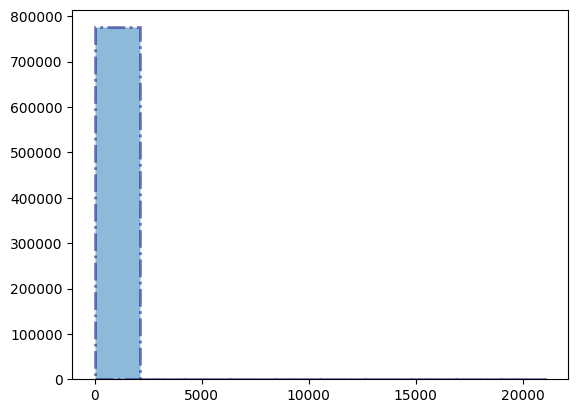

In [ ]:
plt.hist(x = df['nominal_price_eur_amt'],
        bins = 10,
        alpha=0.5,
        linestyle = 'dashdot',
        edgecolor='navy', linewidth = 2,
        histtype = 'bar'
        )
plt.show()

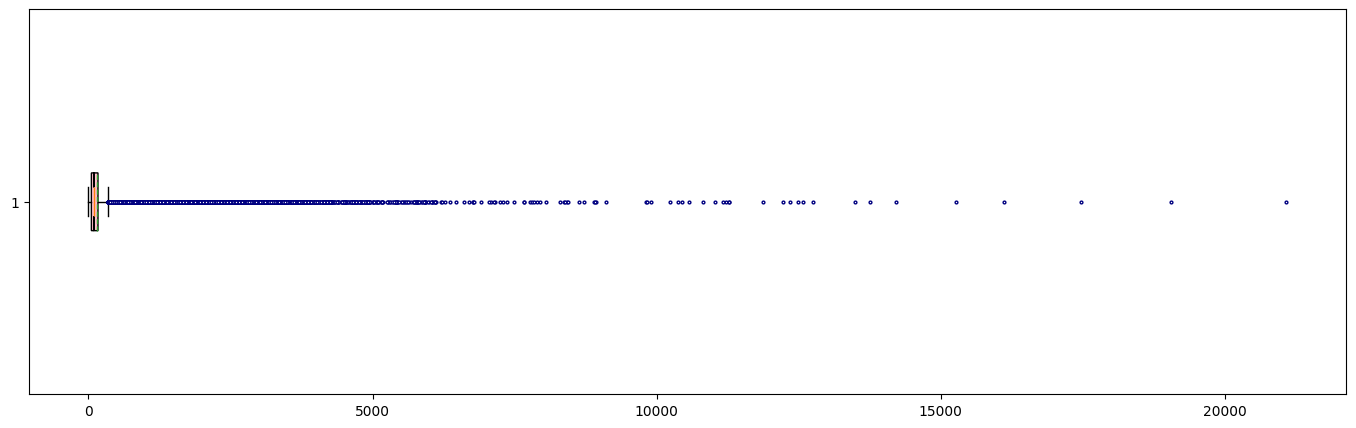

In [ ]:
plt.figure(figsize=(17,5))
plt.boxplot(x=df['nominal_price_eur_amt'], vert=False, patch_artist = True,
            boxprops=dict(facecolor='pink'), meanline=True, showmeans = True, notch=True,
            flierprops=dict(
                markerfacecolor='white',
                marker='o',
                markersize=2,
                linestyle='none',
                markeredgecolor='navy'
                ))
plt.show()

# Часть 2. Разведочный анализ данных (Exploratory Data Analysis — EDA)

Анализ динамики выручки:
 Создайте столбец Revenue (Выручка) = Quantity * UnitPrice.
 Постройте графики динамики общей выручки: по дням недели, по часам (если есть данные о времени), по месяцам.
 Сформулируйте, в какие периоды наблюдаются пики и спады активности. Предположите причины.

Создание новых категориальных признаков:
 Создайте столбец Age_Category на основе возраста (например, "До 18", "18-35", "36-65", "65+").
 Если есть время, создайте столбец Time_of_Day (например, "Утро", "День", "Вечер", "Ночь").
 Создайте любой другой категориальный признак на ваше усмотрение, который, по вашему мнению, может быть полезен для анализа (например, сезон покупки).



In [ ]:
df.rename(columns={"nominal_price_eur_amt": "revenue_eur", "nominal_price_rub_amt": "revenue_rub"}, inplace=True)

df.columns

Index(['order_online_payment_flg', 'account_rk', 'client_rk', 'order_rk',
       'bundle_nm', 'order_type_cd', 'party_first_order_dt', 'created_dttm',
       'promo_code_discount_amt', 'revenue_eur', 'revenue_rub', 'children_cnt',
       'age', 'mobile_phone_operator_nm', 'marital_status_cd',
       'education_level_cd', 'gender_cd'],
      dtype='object')

#### 2.1 Анализ динамики выручки

In [ ]:
df = df[df['created_dttm'] < pd.to_datetime('2024-11-1')]

In [ ]:
df['order_date_year'] = df['created_dttm'].dt.year
df['order_date_month'] = df['created_dttm'].dt.month
df['order_date_day_of_week'] = df['created_dttm'].dt.day_of_week + 1
df['order_date_hour'] = df['created_dttm'].dt.hour

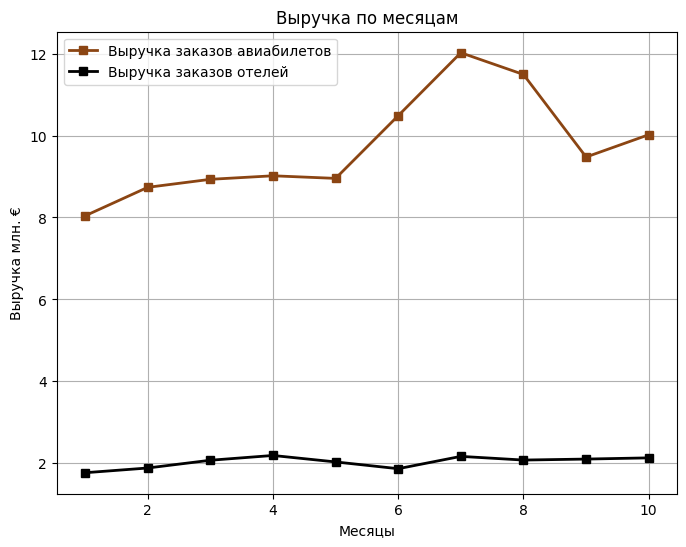

In [ ]:
hours_sum_AIR = df.loc[df['order_type_cd'] == 'AIR', :].groupby('order_date_month')[['revenue_eur']].sum()/1000000.0
hours_sum_HOT = df.loc[df['order_type_cd'] == 'HOT', :].groupby('order_date_month')[['revenue_eur']].sum()/1000000.0

plt.figure(figsize=(8,6))
plt.plot(hours_sum_AIR, label='Выручка заказов авиабилетов', color='saddlebrown', linewidth = 2, marker='s')
plt.plot(hours_sum_HOT, label='Выручка заказов отелей', color='black', linewidth = 2, marker='s')
plt.xlabel('Месяцы')
plt.ylabel('Выручка млн. €')
plt.grid()
plt.title(label='Выручка по месяцам')
plt.legend()
plt.show()

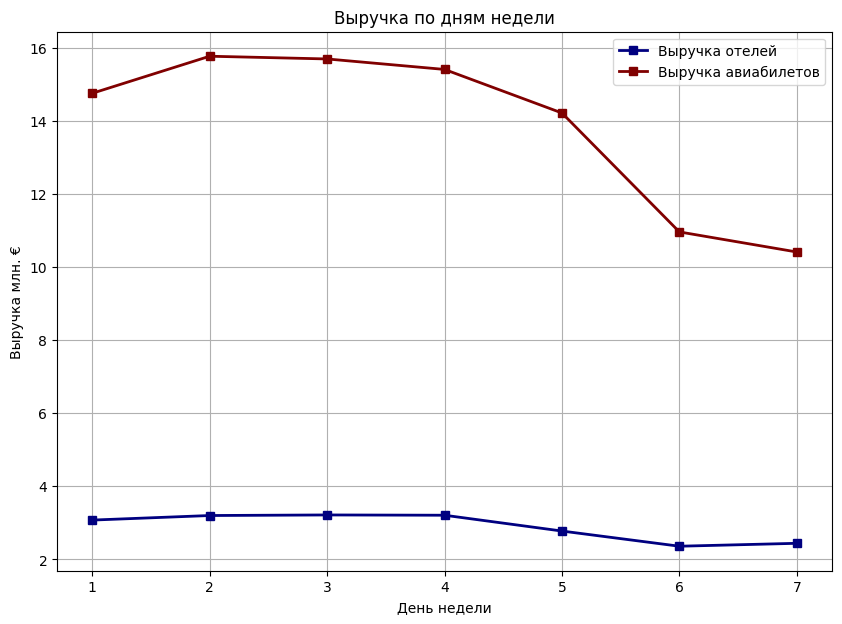

In [ ]:
weekdays_hotels = df[df['order_type_cd']=='HOT'].groupby('order_date_day_of_week')[['revenue_eur']].sum()/1000000.0
weekdays_avia = df[df['order_type_cd']=='AIR'].groupby('order_date_day_of_week')[['revenue_eur']].sum()/1000000.0

#plt.plot(weekdays_sum, label='Выручка по дням недели', color='navy')
#plt.plot(weekdays_count, label='Количество заказов по дням недели', color='maroon')

plt.figure(figsize=(10, 7))
plt.plot(weekdays_hotels, label='Выручка отелей (left)', color='navy', linewidth = 2, marker='s')
plt.plot(weekdays_avia, label='Выручка авиабилетов (right)', color='maroon', linewidth = 2, marker='s')

plt.legend(('Выручка отелей', 'Выручка авиабилетов'))
plt.xlabel('День недели')
plt.ylabel('Выручка млн. €')
plt.grid()
plt.title(label='Выручка по дням недели')
plt.show()

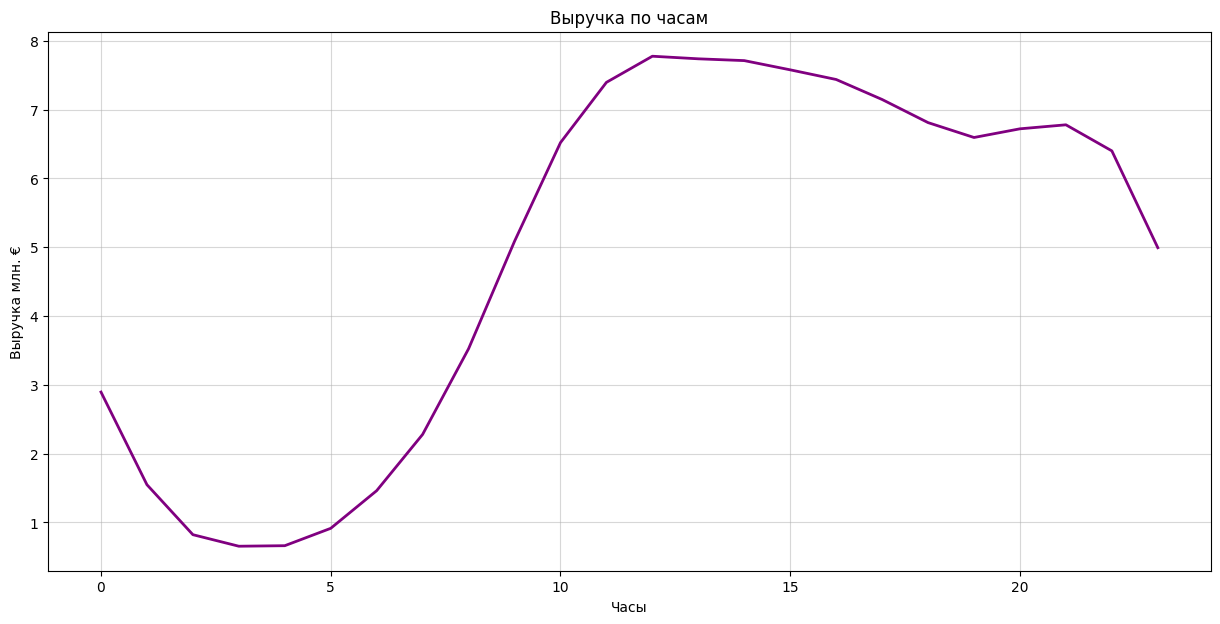

In [ ]:
from matplotlib.lines import lineStyles
from os import linesep
hours_sum = df.groupby('order_date_hour')[['revenue_eur']].sum()/1000000.0

plt.figure(figsize=(15,7))
plt.plot(hours_sum, label='Выручка по часам', color='purple', linewidth = 2)
plt.grid(alpha = 0.5)
plt.xlabel('Часы')
plt.ylabel('Выручка млн. €')
plt.title(label='Выручка по часам')
plt.show()

#### 2.2 Создание новых категориальных признаков

Создание новых категориальных признаков:
 Создайте столбец Age_Category на основе возраста (например, "До 18", "18-35", "36-65", "65+").
 Если есть время, создайте столбец Time_of_Day (например, "Утро", "День", "Вечер", "Ночь").
 Создайте любой другой категориальный признак на ваше усмотрение, который, по вашему мнению, может быть полезен для анализа (например, сезон покупки).



In [ ]:
df['age_category'] = pd.cut(df['age'], bins=[0, 23, 35, 50, 100], labels=['До 23 лет', '23-35 года', '36-50 лет', '50+ лет'])

In [ ]:
df['time_of_day'] = pd.cut(df['order_date_hour'], bins=[0, 5, 11, 17, 23], labels=['Ночь', 'Утро', 'День', 'Вечер'])

education_level_cd
Уровень образования клиента:
SCH — начальное, среднее
GRD — высшее
UGR — неполное высшее
PGR — два высших
ACD — ученая степень

In [ ]:
df['order_type_cd'].value_counts()

,count
order_type_cd,
AIR,596381
HOT,167776


# Раздел 3. Статистические гипотезы

## Визуализация по категориям:
 Постройте столбчатые диаграммы (bar charts), показывающие долю общей выручки по различным категориям, например доля общей выручки по полу или возрастным группам.
 Проанализируйте, какие группы вносят наибольший вклад в выручку.


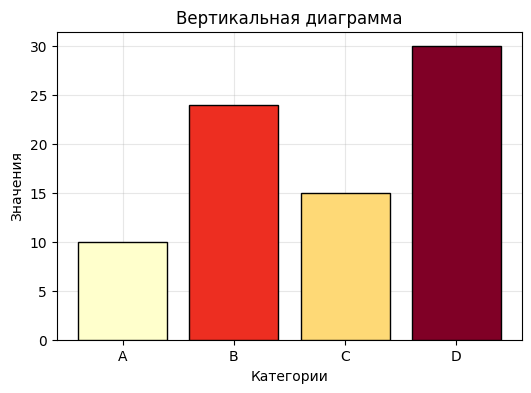

In [ ]:
from matplotlib import cm
categories = ['A', 'B', 'C', 'D']
values = [10, 24, 15, 30]

plt.figure(figsize=(6,4))

# Создание диаграммы
norm = plt.Normalize(min(values), max(values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(values))
plt.bar(categories, values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей
plt.title('Вертикальная диаграмма')
plt.xlabel('Категории')
plt.ylabel('Значения')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Пол

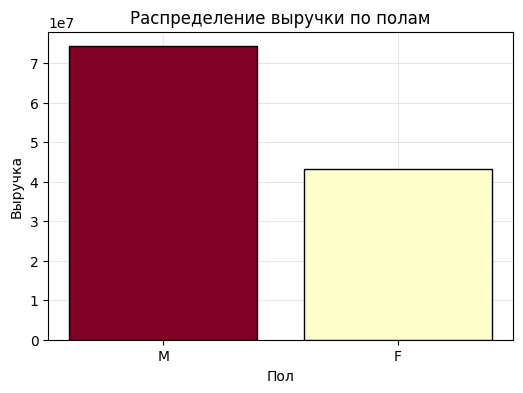

In [ ]:
from matplotlib import cm
gen = df.groupby('gender_cd')['revenue_eur'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))

# Создание диаграммы
norm = plt.Normalize(min(gen.values), max(gen.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(gen.values))
plt.bar(gen.index, gen.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей
plt.title('Распределение выручки по полам')
plt.xlabel('Пол')
plt.ylabel('Выручка')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Образование

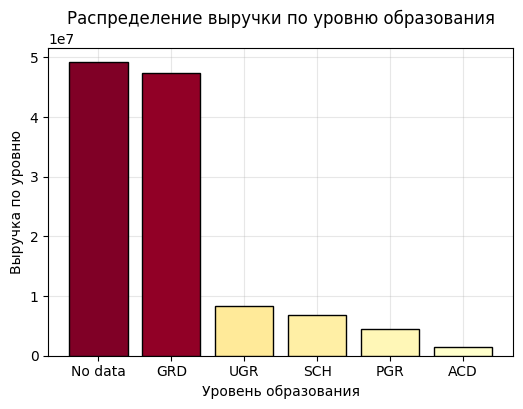

In [ ]:
from matplotlib import cm
educ = df.groupby('education_level_cd')['revenue_eur'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))

# Создание диаграммы
norm = plt.Normalize(min(educ.values), max(educ.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(educ.values))
plt.bar(educ.index, educ.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей
plt.title('Распределение выручки по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Выручка по уровню')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Семейное положение

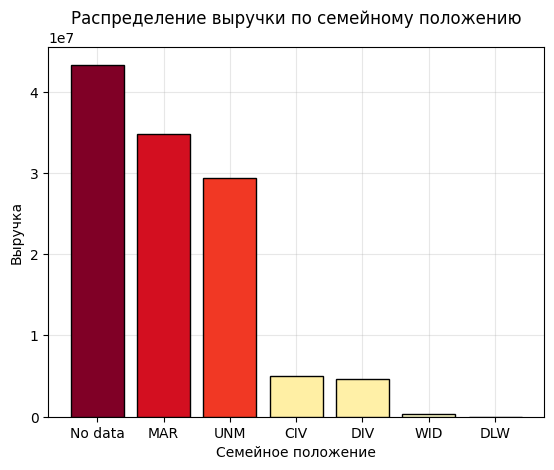

In [ ]:
from matplotlib import cm
fam = df.groupby('marital_status_cd')['revenue_eur'].sum().sort_values(ascending=False)

# Создание диаграммы
norm = plt.Normalize(min(fam.values), max(fam.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(fam.values))
plt.bar(fam.index, fam.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей
plt.title('Распределение выручки по семейному положению')
plt.xlabel('Семейное положение')
plt.ylabel('Выручка')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Возрастным категориям

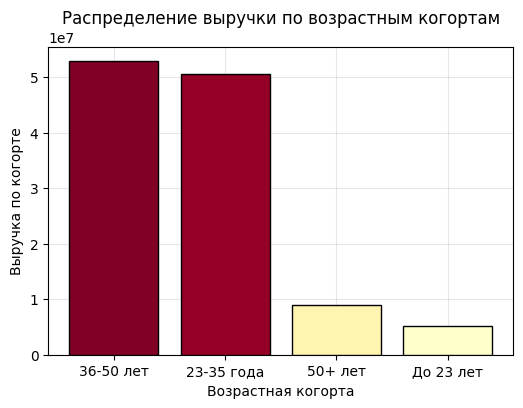

In [ ]:
from matplotlib import cm
agecat = df.groupby('age_category')['revenue_eur'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))

# Создание диаграммы
norm = plt.Normalize(min(agecat.values), max(agecat.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(agecat.values))
plt.bar(agecat.index, agecat.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей
plt.title('Распределение выручки по возрастным когортам')
plt.xlabel('Возрастная когорта')
plt.ylabel('Выручка по когорте')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Оператор моб связи

<Figure size 1000x400 with 0 Axes>

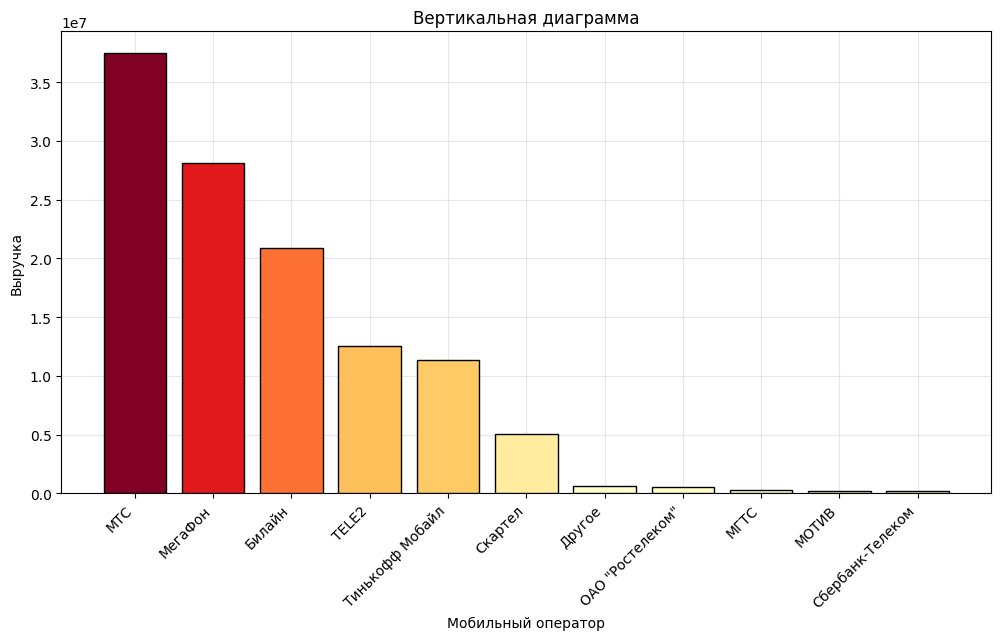

In [ ]:
from matplotlib import cm
mobap = df.groupby('mobile_phone_operator_nm')['revenue_eur'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,4))

# Создание диаграммы
norm = plt.Normalize(min(mobap.values), max(mobap.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(mobap.values))
plt.figure(figsize=(12,6))
plt.bar(mobap.index, mobap.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей

plt.xticks(rotation=45, ha='right')
plt.title('Вертикальная диаграмма')
plt.xlabel('Мобильный оператор')
plt.ylabel('Выручка')

plt.grid(alpha=0.3, zorder=0)

plt.show()

###Подписка

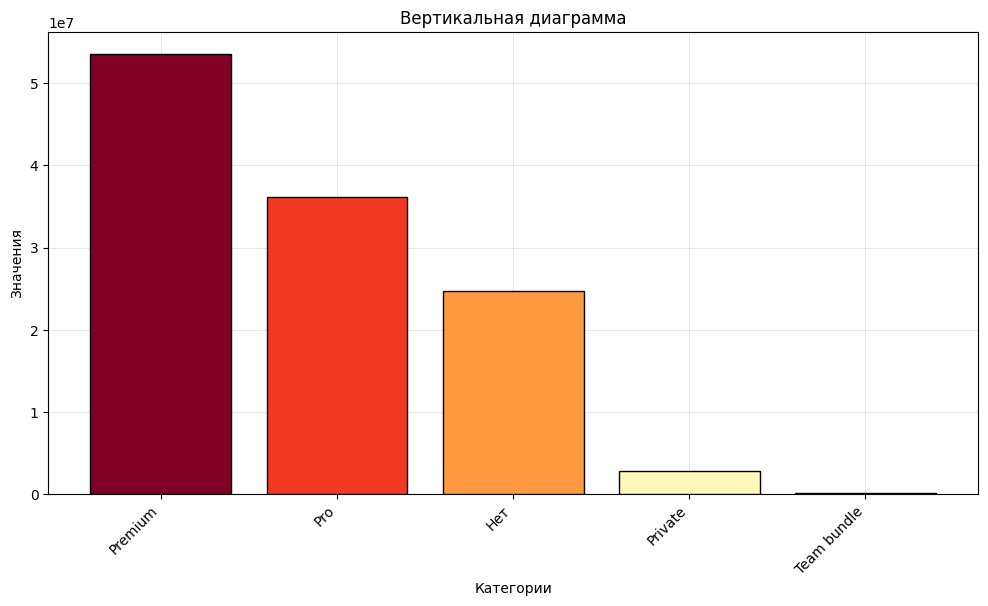

In [ ]:
from matplotlib import cm
bun = df.groupby('bundle_nm')['revenue_eur'].sum().sort_values(ascending=False)

# Создание диаграммы
norm = plt.Normalize(min(bun.values), max(bun.values))
cmap = plt.cm.get_cmap('YlOrRd')
colors = cmap(norm(bun.values))
plt.figure(figsize=(12,6))
plt.bar(bun.index, bun.values, color = colors , edgecolor='black', zorder=3)

# Настройка подписей

plt.xticks(rotation=45, ha='right')
plt.title('Вертикальная диаграмма')
plt.xlabel('Категории')
plt.ylabel('Значения')

plt.grid(alpha=0.3, zorder=0)

plt.show()

## Тест Манна-Уитни по полу

In [ ]:
# гипотеза о равенстве средних

# проверка на нормальность распределения
from scipy.stats import shapiro

print(shapiro(df['revenue_eur']))

ShapiroResult(statistic=np.float64(0.42500847319393187), pvalue=np.float64(2.4322377618747807e-212))


In [ ]:
# данные не распределены нормальность

men = df.query('gender_cd == "M"')['revenue_eur']
women = df.query('gender_cd == "F"')['revenue_eur']

menh = df.query('gender_cd == "M" & order_type_cd == "HOT"')['revenue_eur']
womenh = df.query('gender_cd == "F" & order_type_cd == "HOT"')['revenue_eur']

mena = df.query('gender_cd == "M" & order_type_cd == "AIR"')['revenue_eur']
womena = df.query('gender_cd == "F" & order_type_cd == "AIR"')['revenue_eur']

from scipy.stats import mannwhitneyu

print('Проверка на равенство средних')
print(mannwhitneyu(men, women))
# вывод: среднее двух выборок отличается
print(mannwhitneyu(menh, womenh))
# вывод: среднее двух выборок отличается
print(mannwhitneyu(mena, womena))
# вывод: среднее двух выборок отличается

print('\nВыявляем сторону отклонения')
print(mannwhitneyu(men, women, alternative='less'))
print(mannwhitneyu(menh, womenh, alternative='less'))
# вывод: средний чек женщин в категории отели больше чем у мужчин
print(mannwhitneyu(mena, womena, alternative='greater'))
# вывод: средний чек мужчин в категории авиабилеты больше чем у женщин

Проверка на равенство средних
MannwhitneyuResult(statistic=np.float64(67089529591.5), pvalue=np.float64(2.0351675282198955e-07))
MannwhitneyuResult(statistic=np.float64(3118855527.5), pvalue=np.float64(6.859788976756037e-08))
MannwhitneyuResult(statistic=np.float64(41598195095.5), pvalue=np.float64(0.013719988684393438))

Выявляем сторону отклонения
MannwhitneyuResult(statistic=np.float64(67089529591.5), pvalue=np.float64(1.0175837641099478e-07))
MannwhitneyuResult(statistic=np.float64(3118855527.5), pvalue=np.float64(3.4298944883780185e-08))
MannwhitneyuResult(statistic=np.float64(41598195095.5), pvalue=np.float64(0.006859994342196719))


In [ ]:
mena = df.query('gender_cd == "M" & order_type_cd == "AIR"')['revenue_eur']
womena = df.query('gender_cd == "F" & order_type_cd == "AIR"')['revenue_eur']

from scipy.stats import mannwhitneyu

print(mannwhitneyu(mena, womena))

print('\nВыявляем сторону отклонения')
print(mannwhitneyu(mena, womena, alternative='greater'))

MannwhitneyuResult(statistic=np.float64(41598195095.5), pvalue=np.float64(0.013719988684393438))

Выявляем сторону отклонения
MannwhitneyuResult(statistic=np.float64(41598195095.5), pvalue=np.float64(0.006859994342196719))


##Тест Крускала-Уоллиса по времени суток

In [ ]:
morning = df.loc[(df['time_of_day'] == 'Утро') & (df['order_type_cd'] == "AIR"), 'revenue_eur']
day = df.loc[(df['time_of_day'] == 'День') & (df['order_type_cd'] == "AIR") , 'revenue_eur']
evening = df.loc[(df['time_of_day'] == 'Вечер') & (df['order_type_cd'] == "AIR"), 'revenue_eur']
night = df.loc[(df['time_of_day'] == 'Ночь') & (df['order_type_cd'] == "AIR"), 'revenue_eur']

morningH = df.loc[(df['time_of_day'] == 'Утро') & (df['order_type_cd'] == "HOT"), 'revenue_eur']
dayH = df.loc[(df['time_of_day'] == 'День') & (df['order_type_cd'] == "HOT"), 'revenue_eur']
eveningH = df.loc[(df['time_of_day'] == 'Вечер') & (df['order_type_cd'] == "HOT"), 'revenue_eur']
nightH = df.loc[(df['time_of_day'] == 'Ночь') & (df['order_type_cd'] == "HOT"), 'revenue_eur']

print(shapiro(morning))
print(shapiro(day))
print(shapiro(evening))
print(shapiro(night))
# Нормальности нет

ShapiroResult(statistic=np.float64(0.4126435370038225), pvalue=np.float64(1.0624625352918385e-175))
ShapiroResult(statistic=np.float64(0.4304346936399496), pvalue=np.float64(5.857242802226789e-187))
ShapiroResult(statistic=np.float64(0.4495424769130606), pvalue=np.float64(1.5299479023023388e-180))
ShapiroResult(statistic=np.float64(0.4629430354888302), pvalue=np.float64(3.857097516502679e-120))


In [ ]:
#Тест Крускала-Уоллиса AIR

from scipy.stats import kruskal
#print(kruskal(morning, day, evening, night))
#Попарная проверка равенства средних AIR
print('Проверка на равенство средних (pvalues)')
print("Утро / день", mannwhitneyu(morning, day)[1])
print("Утро / вечер", mannwhitneyu(morning, evening)[1])
print("Утро / ночь", mannwhitneyu(morning, night)[1])
print("День / вечер", mannwhitneyu(day, evening)[1])
print("День / ночь", mannwhitneyu(day, night)[1])
print("Вечер / ночь", mannwhitneyu(evening, night)[1])
#Попарная проверка для выявления сторон отколонения среднего AIR
print('\nВыявление стороны отклонения среднего (pvalues)\nУказанны альтернативные гипотезы')
print("Утро < ДЕНЬ", mannwhitneyu(morning, day, alternative='less')[1])
print("Утро < ВЕЧЕР", mannwhitneyu(morning, evening, alternative='less')[1])
print("Утро < НОЧЬ", mannwhitneyu(morning, night, alternative='less')[1])
print("День < НОЧЬ", mannwhitneyu(day, night, alternative='less')[1])
print("Вечер < НОЧЬ", mannwhitneyu(evening, night, alternative='less')[1])

#Вывод средний чек ночь > день = вечер > утро

Проверка на равенство средних (pvalues)
Утро / день 0.013459493665053578
Утро / вечер 0.00010294124262224502
Утро / ночь 4.913126647433133e-16
День / вечер 0.08635573825756926
День / ночь 1.897843467400205e-12
Вечер / ночь 5.111098085811503e-10

Выявление стороны отклонения среднего (pvalues)
Указанны альтернативные гипотезы
Утро < ДЕНЬ 0.006729746832526789
Утро < ВЕЧЕР 5.147062131112251e-05
Утро < НОЧЬ 2.4565633237165667e-16
День < НОЧЬ 9.489217337001025e-13
Вечер < НОЧЬ 2.5555490429057516e-10


In [ ]:
from scipy.stats import kruskal

morning = df.loc[(df['time_of_day'] == 'Утро') & (df['order_type_cd'] == "AIR"), 'revenue_eur']
day = df.loc[(df['time_of_day'] == 'День') & (df['order_type_cd'] == "AIR") , 'revenue_eur']
evening = df.loc[(df['time_of_day'] == 'Вечер') & (df['order_type_cd'] == "AIR"), 'revenue_eur']
night = df.loc[(df['time_of_day'] == 'Ночь') & (df['order_type_cd'] == "AIR"), 'revenue_eur']

print(kruskal(morning, day, evening, night))

KruskalResult(statistic=np.float64(68.43404667294652), pvalue=np.float64(9.236859518048193e-15))


In [ ]:
print('Проверка на равенство средних для двух выборок (значения pvalues)')
print("Утро = день:", mannwhitneyu(morning, day)[1])
print("Утро = вечер:", mannwhitneyu(morning, evening)[1])
print("Утро = ночь:", mannwhitneyu(morning, night)[1])
print("День = вечер:", mannwhitneyu(day, evening)[1])
print("День = ночь:", mannwhitneyu(day, night)[1])
print("Вечер = ночь:", mannwhitneyu(evening, night)[1])

print('\nВыявление стороны отклонения среднего (pvalues)\nУказаны альтернативные гипотезы при нулевой гипотезе X=Y\n')
print("Утро < ДЕНЬ", mannwhitneyu(morning, day, alternative='less')[1])
print("Утро < ВЕЧЕР", mannwhitneyu(morning, evening, alternative='less')[1])
print("Утро < НОЧЬ", mannwhitneyu(morning, night, alternative='less')[1])
print("День < НОЧЬ", mannwhitneyu(day, night, alternative='less')[1])
print("Вечер < НОЧЬ", mannwhitneyu(evening, night, alternative='less')[1])

Проверка на равенство средних для двух выборок (значения pvalues)
Утро = день: 0.013459493665053578
Утро = вечер: 0.00010294124262224502
Утро = ночь: 4.913126647433133e-16
День = вечер: 0.08635573825756926
День = ночь: 1.897843467400205e-12
Вечер = ночь: 5.111098085811503e-10

Выявление стороны отклонения среднего (pvalues)
Указаны альтернативные гипотезы при нулевой гипотезе X=Y

Утро < ДЕНЬ 0.006729746832526789
Утро < ВЕЧЕР 5.147062131112251e-05
Утро < НОЧЬ 2.4565633237165667e-16
День < НОЧЬ 9.489217337001025e-13
Вечер < НОЧЬ 2.5555490429057516e-10


In [ ]:
#Тест Крускала-Уоллиса HOT

from scipy.stats import kruskal
print(kruskal(morningH, dayH, eveningH, nightH))
#Попарная проверка равенства средних HOT
print('Проверка на равенство средних (pvalues)')
print("Утро / день", mannwhitneyu(morningH, dayH)[1])
print("Утро / вечер", mannwhitneyu(morningH, eveningH)[1])
print("Утро / ночь", mannwhitneyu(morningH, nightH)[1])
print("День / вечер", mannwhitneyu(dayH, eveningH)[1])
print("День / ночь", mannwhitneyu(dayH, nightH)[1])
print("Вечер / ночь", mannwhitneyu(eveningH, nightH)[1])

#Попарная проверка для выявления сторон отколонения среднего HOT
print('\nВыявление стороны отклонения среднего (pvalues)\nУказанны альтернативные гипотезы')
print("Утро < ДЕНЬ", mannwhitneyu(morningH, dayH, alternative='less')[1])
print("Утро < НОЧЬ", mannwhitneyu(morningH, nightH, alternative='less')[1])
print("ДЕНЬ > вечер", mannwhitneyu(dayH, eveningH, alternative='greater')[1])
print("Вечер < НОЧЬ", mannwhitneyu(eveningH, nightH, alternative='less')[1])

#Вывод средний чек ночь = день > утро = вечер

KruskalResult(statistic=np.float64(90.89053257057209), pvalue=np.float64(1.4101741725395855e-19))
Проверка на равенство средних (pvalues)
Утро / день 3.714166275377968e-14
Утро / вечер 0.14760669284601963
Утро / ночь 6.446377479539521e-09
День / вечер 6.463978113758251e-12
День / ночь 0.03885309075301679
Вечер / ночь 5.96623187099677e-07

Выявление стороны отклонения среднего (pvalues)
Указанны альтернативные гипотезы
Утро < ДЕНЬ 1.857083137688984e-14
Утро < НОЧЬ 3.2231887397697606e-09
ДЕНЬ > вечер 3.2319890568791257e-12
Вечер < НОЧЬ 2.983115935498385e-07


##Тест Манна-Уитни (гипотеза клиенты т-мобайл имеют больший чек нежели остальные в связи с большей лояльности к сервису)

In [ ]:
# данные не распределены нормально
tmob = df.query('mobile_phone_operator_nm == "Тинькофф Мобайл"')['revenue_eur']
notmob = df.query('mobile_phone_operator_nm != "Тинькофф Мобайл"')['revenue_eur']

tmob_HOT = df.query('mobile_phone_operator_nm == "Тинькофф Мобайл" & order_type_cd == "HOT"')['revenue_eur']
notmob_HOT = df.query('mobile_phone_operator_nm != "Тинькофф Мобайл" & order_type_cd == "HOT"')['revenue_eur']

tmob_AIR = df.query('mobile_phone_operator_nm == "Тинькофф Мобайл" & order_type_cd == "AIR"')['revenue_eur']
notmob_AIR = df.query('mobile_phone_operator_nm != "Тинькофф Мобайл" & order_type_cd == "AIR"')['revenue_eur']


from scipy.stats import mannwhitneyu

print('Проверка на равенство средних')
print(mannwhitneyu(tmob, notmob))
# вывод: среднее двух выборок совпадает
print(mannwhitneyu(tmob_HOT, notmob_HOT))
# вывод: среднее двух выборок отличается
print(mannwhitneyu(tmob_AIR, notmob_AIR))
# вывод: среднее двух выборок отличается

print('\nВыявляем сторону отклонения')
print(mannwhitneyu(tmob_HOT, notmob_HOT, alternative='less'))
# вывод: средний чек notmob_HOT в категории отели больше чем у tmob_HOT
print(mannwhitneyu(tmob_AIR, notmob_AIR, alternative='greater'))
# вывод: средний чек tmob_AIR в категории авиабилеты больше чем у notmob_AIR

Проверка на равенство средних
MannwhitneyuResult(statistic=np.float64(25186452080.5), pvalue=np.float64(0.445458183975767))
MannwhitneyuResult(statistic=np.float64(1359641271.0), pvalue=np.float64(1.863634330775637e-05))
MannwhitneyuResult(statistic=np.float64(15056087779.5), pvalue=np.float64(8.021136887747964e-16))

Выявляем сторону отклонения
MannwhitneyuResult(statistic=np.float64(1359641271.0), pvalue=np.float64(9.318171653878186e-06))
MannwhitneyuResult(statistic=np.float64(15056087779.5), pvalue=np.float64(4.010568443873982e-16))


## Тест Манна-Уитни (гипотеза клиенты private имеют большее количество заказов нежели остальные)

In [ ]:
# гипотеза о равенстве средних

# проверка на нормальность распределения
from scipy.stats import shapiro

pre_HOT = df.loc[(df['bundle_nm'] == 'Premium') & (df['order_type_cd'] == 'HOT'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pro_HOT = df.loc[(df['bundle_nm'] == 'Pro') & (df['order_type_cd'] == 'HOT'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pri_HOT = df.loc[(df['bundle_nm'] == 'Private') & (df['order_type_cd'] == 'HOT'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
notpr_HOT = df.loc[(df['bundle_nm'] == 'Нет') & (df['order_type_cd'] == 'HOT'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values

pre_AIR = df.loc[(df['bundle_nm'] == 'Premium') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pro_AIR = df.loc[(df['bundle_nm'] == 'Pro') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pri_AIR = df.loc[(df['bundle_nm'] == 'Private') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
notpr_AIR = df.loc[(df['bundle_nm'] == 'Нет') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values

combined_array_HOT = np.concatenate([pre_HOT, pro_HOT, pri_HOT, notpr_HOT])
combined_array_AIR = np.concatenate([pre_AIR, pro_AIR, pri_AIR, notpr_AIR])

print(shapiro(combined_array_HOT))
print(shapiro(combined_array_AIR))
print(shapiro(pre_HOT))
print(shapiro(pro_HOT))
print(shapiro(pri_HOT))
print(shapiro(notpr_HOT))

print(shapiro(pre_AIR))
print(shapiro(pro_AIR))
print(shapiro(pri_AIR))
print(shapiro(notpr_AIR))

ShapiroResult(statistic=np.float64(0.15482440608547965), pvalue=np.float64(3.7278173731919863e-162))
ShapiroResult(statistic=np.float64(0.0340780180352116), pvalue=np.float64(6.05006322182349e-191))
ShapiroResult(statistic=np.float64(0.13096773864626687), pvalue=np.float64(2.003121671401073e-135))
ShapiroResult(statistic=np.float64(0.1979243774335122), pvalue=np.float64(3.577993630506915e-132))
ShapiroResult(statistic=np.float64(0.6307844110686437), pvalue=np.float64(1.2078189266518486e-35))
ShapiroResult(statistic=np.float64(0.1573549698992085), pvalue=np.float64(3.127382889682481e-115))
ShapiroResult(statistic=np.float64(0.21106561698883952), pvalue=np.float64(6.154958026730941e-152))
ShapiroResult(statistic=np.float64(0.07456168485902004), pvalue=np.float64(3.279250792414895e-161))
ShapiroResult(statistic=np.float64(0.5805030403098967), pvalue=np.float64(5.031036017148797e-44))
ShapiroResult(statistic=np.float64(0.013254206344374908), pvalue=np.float64(9.468052199566225e-154))


In [ ]:
pre_AIR = df.loc[(df['bundle_nm'] == 'Premium') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pro_AIR = df.loc[(df['bundle_nm'] == 'Pro') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
pri_AIR = df.loc[(df['bundle_nm'] == 'Private') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values
notpr_AIR = df.loc[(df['bundle_nm'] == 'Нет') & (df['order_type_cd'] == 'AIR'), :].groupby('account_rk')['order_rk'].count().reset_index()['order_rk'].values

combined_array_HOT = np.concatenate([pre_HOT, pro_HOT, pri_HOT, notpr_HOT])
combined_array_AIR = np.concatenate([pre_AIR, pro_AIR, pri_AIR, notpr_AIR])

print(shapiro(combined_array_HOT))
print(shapiro(combined_array_AIR))

print(kruskal(pre_AIR, pro_AIR, pri_AIR, notpr_AIR))

print('\nРезультаты теста Манна-Уитни')

print(mannwhitneyu(notpr_AIR, pre_AIR))
print(mannwhitneyu(pri_AIR, pre_AIR))
print(mannwhitneyu(pri_AIR, pro_AIR))
print(mannwhitneyu(pri_AIR, notpr_AIR))

print('\nВыявляем сторону отклонения')
print(mannwhitneyu(notpr_AIR, pre_AIR, alternative='less'))
print(mannwhitneyu(pri_AIR, pre_AIR, alternative='greater'))
print(mannwhitneyu(pri_AIR, pro_AIR, alternative='greater'))
print(mannwhitneyu(pri_AIR, notpr_AIR, alternative='greater'))
# вывод: гипотеза подтверждается


ShapiroResult(statistic=np.float64(0.15482440608547965), pvalue=np.float64(3.7278173731919863e-162))
ShapiroResult(statistic=np.float64(0.0340780180352116), pvalue=np.float64(6.05006322182349e-191))
KruskalResult(statistic=np.float64(460.64072033841643), pvalue=np.float64(1.6132418790505032e-99))

Результаты теста Манна-Уитни
MannwhitneyuResult(statistic=np.float64(729167246.0), pvalue=np.float64(1.4416206216091186e-88))
MannwhitneyuResult(statistic=np.float64(24059091.0), pvalue=np.float64(1.5432374631440013e-06))
MannwhitneyuResult(statistic=np.float64(28870365.5), pvalue=np.float64(6.27961884611761e-14))
MannwhitneyuResult(statistic=np.float64(21687411.5), pvalue=np.float64(1.2837601631779223e-20))

Выявляем сторону отклонения
MannwhitneyuResult(statistic=np.float64(729167246.0), pvalue=np.float64(7.208103108045593e-89))
MannwhitneyuResult(statistic=np.float64(24059091.0), pvalue=np.float64(7.716187315720006e-07))
MannwhitneyuResult(statistic=np.float64(28870365.5), pvalue=np.float6

In [ ]:
# данные не распределены нормально
from scipy.stats import kruskal

print('Проверка на равенство средних')
print(kruskal(pre_HOT, pro_HOT, pri_HOT, notpr_HOT))
print(kruskal(pre_AIR, pro_AIR, pri_AIR, notpr_AIR))
# вывод: среднее всех трех выборок отличается

print(mannwhitneyu(pri_HOT, pre_HOT))
print(mannwhitneyu(pri_HOT, pro_HOT))
print(mannwhitneyu(pri_HOT, notpr_HOT))

print(mannwhitneyu(pri_AIR, pre_AIR))
print(mannwhitneyu(pri_AIR, pro_AIR))
print(mannwhitneyu(pri_AIR, notpr_AIR))
# вывод: среднее всех двух выборок отличается


print('\nВыявляем сторону отклонения')
print(mannwhitneyu(pri_HOT, pre_HOT, alternative='greater'))
print(mannwhitneyu(pri_HOT, pre_HOT, alternative='greater'))
print(mannwhitneyu(pri_HOT, notpr_HOT, alternative='greater'))
print(mannwhitneyu(pri_AIR, pre_AIR, alternative='greater'))
print(mannwhitneyu(pri_AIR, pro_AIR, alternative='greater'))
print(mannwhitneyu(pri_AIR, notpr_AIR, alternative='greater'))
# вывод: гипотеза подтверждается


Проверка на равенство средних
KruskalResult(statistic=np.float64(146.49745809001726), pvalue=np.float64(1.5006210045375775e-31))
KruskalResult(statistic=np.float64(460.64072033841643), pvalue=np.float64(1.6132418790505032e-99))
MannwhitneyuResult(statistic=np.float64(8294717.0), pvalue=np.float64(7.627981450078727e-05))
MannwhitneyuResult(statistic=np.float64(8355467.0), pvalue=np.float64(3.545677438206827e-09))
MannwhitneyuResult(statistic=np.float64(4536093.5), pvalue=np.float64(1.2739912157155874e-11))
MannwhitneyuResult(statistic=np.float64(24059091.0), pvalue=np.float64(1.5432374631440013e-06))
MannwhitneyuResult(statistic=np.float64(28870365.5), pvalue=np.float64(6.27961884611761e-14))
MannwhitneyuResult(statistic=np.float64(21687411.5), pvalue=np.float64(1.2837601631779223e-20))

Выявляем сторону отклонения
MannwhitneyuResult(statistic=np.float64(8294717.0), pvalue=np.float64(3.8139907250393635e-05))
MannwhitneyuResult(statistic=np.float64(8294717.0), pvalue=np.float64(3.8139907

##Вывод

В дальнейшем RFM анализе не целисообразно использовать такие категории как: люди с подпиской Private и Team

# Раздел 3.99. RFM анализ

#RFM анализ AIR


In [ ]:
dfrfm_AIR = df.loc[(df['bundle_nm'] != 'Private') & (df['bundle_nm'] != 'Team bundle') & (df['order_type_cd'] == 'AIR') , :]

dfrfm_AIR['order_recency'] = pd.to_datetime('2024-11-01') - (dfrfm_AIR['created_dttm'])

In [ ]:
rfm = dfrfm_AIR.groupby('client_rk').agg(
    recency = ('order_recency', lambda x: x.min().days),
    frequency = ('order_rk', 'nunique'),
    monetary_value = ('revenue_eur', 'sum')
).reset_index()

In [ ]:
rfm['recency']

,recency
0,148
1,208
2,10
3,96
4,136
...,...
85109,28
85110,214
85111,78
85112,51


In [ ]:
rfm['r'] = pd.cut(rfm['recency'], [-1.0, 30.0, 90.0, 1000.0], labels=[3,2,1])
rfm['f'] = pd.cut(rfm['frequency'], [-1, 3, 7, 1000.0], labels=[1,2,3])
rfm['m'] = pd.cut(rfm['monetary_value'], [-1.0, 150.0, 500, 5000000.0], labels=[1,2,3])

display(rfm.head(10))

,client_rk,recency,frequency,monetary_value,r,f,m
0,000047e2e70a562001b2b9230bc95c7efcb1103b327171...,148,5,319.0,1,2,2
1,00019ea581c09c72f249b6714222e8931e30448f7ed2eb...,208,6,479.0,1,2,2
2,0001d4e275c931cb346856169aa616a8dd14c04de1d21d...,10,14,2451.0,3,3,3
3,00026eedb1d8d983a35b3d4240e377d6e139baad27469b...,96,4,760.0,1,2,3
4,00031d8f8196b4e2effb4fad8423fe90c39178bbe5cff9...,136,5,2277.0,1,2,3
5,00033429ebf9d24fe164112ee128a85614e41fd2469855...,5,4,1484.0,3,2,3
6,0004ee50854e1838b574cee2bbb53a6ba6993dbdeb8caf...,50,2,195.0,2,1,2
7,00054613d5c6532885fc55ead9d581d4b169af7da53379...,73,11,942.0,2,3,3
8,0005f720d8b800a5e19533d3717ea93ae7d195164211c4...,283,1,135.0,1,1,1
9,0006484d6fd1beaa0c454c07877c6c9ca7bd2076b4ab4b...,139,8,531.0,1,3,3


In [ ]:
pd.set_option('display.max_rows', 1000)
display(rfm['monetary_value'].value_counts().sort_values(ascending = False))

,count
monetary_value,
270.0,103
266.0,101
269.0,100
501.0,97
340.0,97
...,...
5258.0,1
7710.0,1
16349.0,1


In [ ]:
rfm[['r','f','m']] = rfm[['r','f','m']].astype('str')
rfm['rfm_group'] = rfm['r'] + rfm['f'] + rfm['m']

rfm[['r','f','m']] = rfm[['r','f','m']].astype('int')

rfm['rfm_sum'] = rfm[['r','f','m']].sum(axis=1)

In [ ]:
rfm_group = rfm.groupby('rfm_group').agg(
    {'client_rk':'nunique',
     'rfm_sum':'mean'}
).reset_index()
display(rfm_group.sort_values('client_rk'))

,rfm_group,client_rk,rfm_sum
6,131,3,5.0
20,321,87,6.0
12,221,121,5.0
3,121,163,4.0
7,132,211,6.0
15,232,387,7.0
23,332,518,8.0
17,311,785,5.0
19,313,1217,7.0
9,211,1504,4.0


In [ ]:
import plotly.express as px

fig = px.treemap(rfm_group,
                 path = ['rfm_group'],
                 values = 'client_rk',
                 color = 'rfm_sum',
                 color_continuous_scale = 'Sunset',
                 title = 'RFM сегментация пользователей')
fig.show()

Отлично, теперь у нас RFM-сегментация пользователей **приложения для покупки авиабилетов**. Хотя структура сегментов похожа на предыдущую (отель), поведение клиентов в авиасекторе имеет свои особенности: чаще — спонтанные/плановые покупки, меньшая частота, большая чувствительность к цене и датам.

Разберем сегментацию и предложим **целевые маркетинговые стратегии**, адаптированные под специфику авиабилетов.

---

## 🔍 **Вывод анализа RFM (Авиабилеты)**

Как и ранее:
*   **R (Recency)** — 1 = давно, 3 = недавно.
*   **F (Frequency)** — 1 = редко, 3 = часто.
*   **M (Monetary)** — 1 = мало, 3 = много.
*   **Цвет** — `rfm_sum` (от 3 до 9). Фиолетовый = ценнее.
*   **Размер** — количество пользователей в сегменте.

### 📊 Ключевые наблюдения

1.  **Доминирующий сегмент:**
    *   **111 (R=1, F=1, M=1)** — самый большой сегмент. Это "одноразовые" или "спящие" пользователи. Возможно, они купили билет один раз (например, по акции) и больше не возвращались. Их нужно либо активировать, либо отсеять.

2.  **Средние сегменты (основная масса):**
    *   **112 (R=1, F=1, M=2)** — крупный сегмент. Пользователи, которые тратят средние суммы, но редко и давно не были активны. Есть потенциал к росту.
    *   **211 (R=2, F=1, M=1)** — недавно активные, но тратят мало и редко. Возможно, это бюджетные путешественники или новички.
    *   **212 (R=2, F=1, M=2)** — перспективные: недавно купили, тратят среднее, можно мотивировать на повторные покупки.

3.  **Ценные сегменты (высокий rfm_sum):**
    *   **333 (R=3, F=3, M=3)** — "Золотые клиенты". Активны, часто летают, тратят много. Вероятно, бизнес-путешественники или частые туристы.
    *   **323 (R=3, F=2, M=3)** — "Потенциально золотые". Недавно активны, тратят много, но еще не стали частыми покупателями. Их нужно мотивировать на повторные покупки.
    *   **332 (R=3, F=3, M=2)** — "Лояльные, но экономные". Часто летают, недавно активны, тратят средние суммы. Можно мотивировать на покупку более дорогих билетов или дополнительных услуг.
    *   **233 (R=2, F=3, M=3)** — "Частые тратящие". Часто покупают, тратят много, но последняя покупка была не совсем недавно. Нужно вернуть их в активность.

4.  **Сегменты риска:**
    *   **311 (R=3, F=1, M=1)** — "Новые/случайные, но активные". Недавно купили, но тратят мало и редко. Риск, что это одноразовые клиенты.
    *   **131 (R=1, F=3, M=1)** — "Старые лояльные, но низкочековые". Часто покупают, но тратят мало. Возможно, они всегда выбирают самые дешевые билеты или используют только базовые услуги.

---

## 🎯 **Маркетинговые стратегии по сегментам (Авиабилеты)**

Объединим сегменты в группы и предложим целевые стратегии, **учитывая специфику авиабилетов**: сезонность, цена, гибкость дат, дополнительные услуги (багаж, питание, выбор места).

---

### 🟢 Группа 1: **"Золотые клиенты" (rfm_sum 8-9)**
*   **Сегменты:** 333, 323, 332, 233
*   **Характеристика:** Высокая ценность, высокая лояльность, высокий потенциал дохода. Часто летают, тратят много.
*   **Стратегия: Удержание и усиление лояльности**
    *   **VIP-программа:** Бесплатное повышение класса, приоритетная регистрация, бесплатный багаж, доступ в залы ожидания.
    *   **Персонализированные предложения:** Эксклюзивные тарифы, ранний доступ к распродажам, предложения по популярным направлениям.
    *   **Программа лояльности премиум-уровня:** Начисление миль/баллов за каждую покупку, обмен на премиальные билеты или услуги.
    *   **Персональный менеджер:** Предложение услуг персонального помощника в подборе рейсов, изменении дат, оформлении виз.
    *   **Кросс-продажи:** Предлагать дополнительные услуги (багаж, питание, выбор места, страхование) или пакеты (авиабилет + отель).
    *   **Бонусы за частоту:** Например, каждый 5-й билет — со скидкой 20%.

---

### 🟡 Группа 2: **"Перспективные клиенты" (rfm_sum 6-7)**
*   **Сегменты:** 312, 313, 223, 232, 222, 123, 132, 322
*   **Характеристика:** Средняя/высокая ценность, есть потенциал роста. Нужно повысить частоту или размер покупок.
*   **Стратегия: Активация и рост**
    *   **Таргетированные email/SMS-кампании:** Напомнить о последнем просмотре рейса, предложить скидку на следующую покупку.
    *   **Программа лояльности (базовая):** Начисление бонусов, скидки за вторую покупку.
    *   **Апсейл и кросс-продажи:** Предлагать более комфортные места, дополнительный багаж, страхование, пакеты (авиабилет + отель).
    *   **Персонализированные рекомендации:** На основе истории просмотров и покупок (например, "Вы часто летаете в Турцию — вот лучшие предложения на этот месяц").
    *   **Ограниченные предложения:** "Только для вас: скидка 10% на следующее бронирование в течение 7 дней".
    *   **Гибкость дат:** Предлагать альтернативные даты с более выгодными тарифами.

---

### 🟠 Группа 3: **"Спящие / Случайные клиенты" (rfm_sum 4-5)**
*   **Сегменты:** 211, 212, 121, 122, 113, 131, 221, 311
*   **Характеристика:** Низкая/средняя ценность, низкая активность или частота. Есть шанс реанимировать.
*   **Стратегия: Реактивация и пробуждение интереса**
    *   **Реактивационные кампании:** "Мы скучаем по вам! Получите 15% скидку на ваше следующее бронирование".
    *   **Рассказы о новых возможностях:** Email с обзором новых направлений, функций приложения, акций.
    *   **Бонус за возвращение:** Начисление бонусных баллов за первую покупку после долгого перерыва.
    *   **Социальные доказательства:** Отзывы других пользователей, рейтинги авиакомпаний, популярные направления.
    *   **Опросы:** "Что бы вы хотели видеть в нашем приложении?" — помогает понять причины оттока.
    *   **Ценовые триггеры:** "Самые низкие цены на эту неделю", "Только сегодня: скидка 20% на рейсы в Европу".

---

### 🔴 Группа 4: **"Низкая ценность / Риск оттока" (rfm_sum 3)**
*   **Сегменты:** 111, 112, 211 (если не включен в группу 3)
*   **Характеристика:** Самый большой сегмент, но с минимальной ценностью. Большинство — новые или одноразовые пользователи.
*   **Стратегия: Минимизация затрат / Тестирование**
    *   **Автоматизированные приветственные кампании:** Для новых пользователей — обучение, первая скидка.
    *   **Глубокая сегментация внутри группы:** Разделить на "новые" и "старые неактивные". Для новых — фокус на onboarding, для старых — реактивация.
    *   **Упрощение процесса покупки:** Убедиться, что поиск и бронирование максимально простое и быстрое.
    *   **Тестирование гипотез:** Запустить A/B тесты с разными предложениями (скидки, бонусы, контент) для понимания, что работает.
    *   **Минимизация маркетинговых затрат:** Не тратить большие бюджеты на рекламу для этой группы без проверки ROI.
    *   **Фокус на цене:** Для этого сегмента ключевой фактор — стоимость. Предлагать самые дешевые варианты, акции, распродажи.

---

## 📈 **Общие выводы и рекомендации (Авиабилеты)**

1.  **Фокус на "Золотых клиентах":** Хотя их мало, они приносят основной доход. Инвестируйте в их удержание и удовлетворенность.
2.  **Активация "Перспективных":** Это ваша будущая база. Стратегии должны быть направлены на увеличение частоты и размера покупок.
3.  **Реактивация "Спящих":** Большой потенциал для роста. Используйте персонализированные и эмоциональные сообщения.
4.  **Оптимизация работы с "Низкозначимыми":** Не игнорируйте, но не тратите ресурсы без измерения эффективности. Фокус на автоматизации и A/B тестах.
5.  **Интеграция данных:** Свяжите RFM с данными о поведении в приложении (просмотренные рейсы, добавленные в избранное, время сессии) для еще более точной персонализации.
6.  **Динамика сегментов:** RFM — не статичная модель. Пересчитывайте сегменты ежемесячно и адаптируйте стратегии.
7.  **Учет сезонности:** В авиасекторе очень важна сезонность. Адаптируйте предложения под праздники, отпуска, деловые поездки.
8.  **Гибкость и удобство:** Для авиабилетов критически важны гибкость дат, простота изменения бронирования, прозрачность цен (без скрытых сборов).

---

Эта стратегия позволит вам не просто сегментировать пользователей, а **системно влиять на их поведение**, увеличивая LTV (пожизненную ценность) и общую прибыльность бизнеса в авиасекторе.

#RFM анализ HOT


In [ ]:
dfrfm_HOT = df.loc[(df['bundle_nm'] != 'Private') & (df['bundle_nm'] != 'Team bundle') & (df['order_type_cd'] == 'HOT') , :]

dfrfm_HOT['order_recency'] = pd.to_datetime('2024-11-01') - (dfrfm_HOT['created_dttm'])

In [ ]:
rfm = dfrfm_HOT.groupby('client_rk').agg(
    recency = ('order_recency', lambda x: x.min().days),
    frequency = ('order_rk', 'nunique'),
    monetary_value = ('revenue_eur', 'sum')
).reset_index()

In [ ]:
rfm['r'] = pd.cut(rfm['recency'], [-1.0, 30.0, 90.0, 1000.0], labels=[3,2,1])
rfm['f'] = pd.cut(rfm['frequency'], [-1, 5, 15, 1000.0], labels=[1,2,3])
rfm['m'] = pd.cut(rfm['monetary_value'], [-1.0, 110.0, 500, 5000000.0], labels=[1,2,3])

display(rfm.head(10))

,client_rk,recency,frequency,monetary_value,r,f,m
0,00023bb2f46b332c4a84cf3391a6be24b05cedad6f4897...,246,1,30.0,1,1,1
1,00025fad046ff0ce2c86eb2fe19641c56f13034e922420...,140,5,194.0,1,1,2
2,00031d8f8196b4e2effb4fad8423fe90c39178bbe5cff9...,213,1,476.0,1,1,2
3,00033429ebf9d24fe164112ee128a85614e41fd2469855...,50,5,690.0,2,1,3
4,0003c1dee6c1850e0e173a47eeaaf8f10badb88d371add...,142,3,288.0,1,1,2
5,000477d1917378a70dc98d732ab3580b207d67d4abd1c6...,25,3,167.0,3,1,2
6,0004ee50854e1838b574cee2bbb53a6ba6993dbdeb8caf...,198,1,14.0,1,1,1
7,0005f720d8b800a5e19533d3717ea93ae7d195164211c4...,65,7,379.0,2,2,2
8,00072ddf67bf841725513b9569bda2a1837f851c9d8cba...,121,2,50.0,1,1,1
9,00088752aa0bf1922bfed3094508d9edcb6f98206a1526...,45,1,26.0,2,1,1


In [ ]:
pd.set_option('display.max_rows', 1000)
display(rfm['monetary_value'].value_counts().sort_values(ascending = False))

,count
monetary_value,
24.0,211
29.0,200
25.0,195
27.0,193
28.0,191
...,...
2036.0,1
4741.0,1
3546.0,1


In [ ]:
rfm[['r','f','m']] = rfm[['r','f','m']].astype('str')
rfm['rfm_group'] = rfm['r'] + rfm['f'] + rfm['m']

rfm[['r','f','m']] = rfm[['r','f','m']].astype('int')

rfm['rfm_sum'] = rfm[['r','f','m']].sum(axis=1)

In [ ]:
rfm_group = rfm.groupby('rfm_group').agg(
    {'client_rk':'nunique',
     'rfm_sum':'mean'}
).reset_index()
display(rfm_group.sort_values('client_rk'))

,rfm_group,client_rk,rfm_sum
22,331,1,7.0
6,132,6,6.0
14,232,13,7.0
23,332,26,8.0
11,221,37,5.0
19,321,38,6.0
7,133,49,7.0
3,121,49,4.0
15,233,109,8.0
24,333,333,9.0


In [ ]:
import plotly.express as px

fig = px.treemap(rfm_group,
                 path = ['rfm_group'],
                 values = 'client_rk',
                 color = 'rfm_sum',
                 color_continuous_scale = 'Sunset',
                 title = 'RFM сегментация пользователей')
fig.show()

Отлично, у нас есть визуализация RFM-сегментации пользователей приложения для бронирования отелей. Давайте разберем ее и предложим целевые маркетинговые стратегии.

---

## 🔍 **Вывод анализа RFM**

RFM (Recency, Frequency, Monetary) — это классический метод сегментации клиентов по трем ключевым параметрам:

*   **R (Recency)** — насколько недавно клиент совершал покупку (1 = давно, 3 = недавно).
*   **F (Frequency)** — как часто клиент совершает покупки (1 = редко, 3 = часто).
*   **M (Monetary)** — сколько клиент тратит (1 = мало, 3 = много).

На графике:
*   **Цвет** показывает `rfm_sum` — сумму трех оценок (от 3 до 9). Чем темнее цвет (фиолетовый), тем ценнее сегмент.
*   **Размер прямоугольника** пропорционален количеству пользователей в сегменте.

### 📊 Ключевые наблюдения

1.  **Доминирующие сегменты:**
    *   **111 (R=1, F=1, M=1)** — самый большой сегмент. Это "спящие" или "новые/случайные" пользователи: они давно не активны, совершают мало покупок и тратят мало. Их нужно активировать или отсеять.
    *   **112 (R=1, F=1, M=2)** — также очень крупный сегмент. Пользователи, которые тратят средние суммы, но редко и давно не были активны. Есть потенциал к росту.
    *   **212 (R=2, F=1, M=2)** — значительный сегмент "перспективных". Они недавно были активны, тратят средние суммы, но пока редко. Их можно перевести в частых покупателей.

2.  **Ценные сегменты (высокий rfm_sum):**
    *   **333 (R=3, F=3, M=3)** — "Золотые клиенты". Маленький, но самый ценный сегмент: активны, часто покупают, тратят много. Их нужно лояльно удерживать.
    *   **323 (R=3, F=2, M=3)** — "Потенциально золотые". Недавно активны, тратят много, но еще не стали частыми покупателями. Их нужно мотивировать на повторные покупки.
    *   **332 (R=3, F=3, M=2)** — "Лояльные тратящие". Часто покупают, недавно активны, тратят средние суммы. Можно мотивировать на увеличение чека.
    *   **233 (R=2, F=3, M=3)** — "Частые тратящие". Часто покупают, тратят много, но последняя покупка была не совсем недавно. Нужно вернуть их в активность.

3.  **Сегменты риска:**
    *   **311 (R=3, F=1, M=1)** — "Новые/случайные, но активные". Недавно купили, но тратят мало и редко. Риск, что это одноразовые клиенты.
    *   **131 (R=1, F=3, M=1)** — "Старые лояльные, но низкочековые". Часто покупают, но тратят мало. Возможно, они используют только дешевые опции или нуждаются в стимуляции к увеличению чека.

---

## 🎯 **Маркетинговые стратегии по сегментам**

Для эффективности объединим сегменты в группы и предложим целевые стратегии.

---

### 🟢 Группа 1: **"Золотые клиенты" (rfm_sum 8-9)**
*   **Сегменты:** 333, 323, 332, 233
*   **Характеристика:** Высокая ценность, высокая лояльность, высокий потенциал дохода.
*   **Стратегия: Удержание и усиление лояльности**
    *   **Персонализированные предложения:** VIP-доступ, эксклюзивные скидки, ранний доступ к новым отелям или акциям.
    *   **Программа лояльности премиум-уровня:** Бонусы за каждую покупку, бесплатное повышение категории номера, бесплатный трансфер.
    *   **Персональный менеджер / консьерж:** Предложение услуг персонального помощника в подборе отелей.
    *   **Обратная связь и вовлечение:** Опросы, возможность участвовать в тестировании новых функций, приглашения на закрытые мероприятия.
    *   **Кросс-продажи и апсейлы:** Предлагать дополнительные услуги (экскурсии, спа, трансфер) или более дорогие категории номеров.

---

### 🟡 Группа 2: **"Перспективные клиенты" (rfm_sum 6-7)**
*   **Сегменты:** 312, 313, 223, 232, 222, 123, 132, 322
*   **Характеристика:** Средняя/высокая ценность, есть потенциал роста. Нужно повысить частоту или размер покупок.
*   **Стратегия: Активация и рост**
    *   **Таргетированные email/SMS-кампании:** Напомнить о последнем просмотре отеля, предложить скидку на следующую покупку.
    *   **Программа лояльности (базовая):** Начисление бонусов, скидки за вторую покупку.
    *   **Апсейл и кросс-продажи:** Предлагать пакеты (отель + экскурсия), более комфортные номера со скидкой.
    *   **Персонализированные рекомендации:** На основе истории просмотров и покупок.
    *   **Ограниченные предложения:** "Только для вас: скидка 10% на следующее бронирование в течение 7 дней".

---

### 🟠 Группа 3: **"Спящие / Случайные клиенты" (rfm_sum 4-5)**
*   **Сегменты:** 211, 212, 121, 122, 113, 131, 221, 311
*   **Характеристика:** Низкая/средняя ценность, низкая активность или частота. Есть шанс реанимировать.
*   **Стратегия: Реактивация и пробуждение интереса**
    *   **Реактивационные кампании:** "Мы скучаем по вам! Получите 15% скидку на ваше следующее бронирование".
    *   **Рассказы о новых возможностях:** Email с обзором новых отелей, функций приложения, акций.
    *   **Бонус за возвращение:** Начисление бонусных баллов за первую покупку после долгого перерыва.
    *   **Социальные доказательства:** Отзывы других пользователей, рейтинги отелей, популярные направления.
    *   **Опросы:** "Что бы вы хотели видеть в нашем приложении?" — помогает понять причины оттока.

---

### 🔴 Группа 4: **"Низкая ценность / Риск оттока" (rfm_sum 3)**
*   **Сегменты:** 111, 112, 211 (если не включен в группу 3)
*   **Характеристика:** Самый большой сегмент, но с минимальной ценностью. Большинство — новые или одноразовые пользователи.
*   **Стратегия: Минимизация затрат / Тестирование**
    *   **Автоматизированные приветственные кампании:** Для новых пользователей — обучение, первая скидка.
    *   **Глубокая сегментация внутри группы:** Разделить на "новые" и "старые неактивные". Для новых — фокус на onboarding, для старых — реактивация.
    *   **Упрощение процесса покупки:** Убедиться, что бронирование максимально простое и быстрое.
    *   **Тестирование гипотез:** Запустить A/B тесты с разными предложениями (скидки, бонусы, контент) для понимания, что работает.
    *   **Минимизация маркетинговых затрат:** Не тратить большие бюджеты на рекламу для этой группы без проверки ROI.

---

## 📈 **Общие выводы и рекомендации**

1.  **Фокус на "Золотых клиентах":** Хотя их мало, они приносят основной доход. Инвестируйте в их удержание и удовлетворенность.
2.  **Активация "Перспективных":** Это ваша будущая база. Стратегии должны быть направлены на увеличение частоты и размера покупок.
3.  **Реактивация "Спящих":** Большой потенциал для роста. Используйте персонализированные и эмоциональные сообщения.
4.  **Оптимизация работы с "Низкозначимыми":** Не игнорируйте, но не тратите ресурсы без измерения эффективности. Фокус на автоматизации и A/B тестах.
5.  **Интеграция данных:** Свяжите RFM с данными о поведении в приложении (просмотренные отели, добавленные в избранное, время сессии) для еще более точной персонализации.
6.  **Динамика сегментов:** RFM — не статичная модель. Пересчитывайте сегменты ежемесячно и адаптируйте стратегии.

---

Эта стратегия позволит вам не просто сегментировать пользователей, а **системно влиять на их поведение**, увеличивая LTV (пожизненную ценность) и общую прибыльность бизнеса.

# Часть 4. Прогнозирование выручки с использованием моделей временных рядов


### Подготовка к прогнозированию

1. Подготовка данных
 Создайте датафрейм из двух столбцов: date (дата) и sales (продажи/выручка).
 Преобразуйте столбец date в тип datetime.
 Установите date в качестве индекса датафрейма (df.set_index('date', inplace=True)).
 Проверьте данные на пропуски и дубликаты. Решите, как их обработать (интерполяция, заполнение средним и т.д.).


In [ ]:
df_AIR_ = df.loc[(df['order_type_cd'] == "AIR") & (df['created_dttm']<'2024-10-30'),['created_dttm', 'revenue_eur']]
df_HOT_ = df.loc[(df['order_type_cd'] == "HOT") & (df['created_dttm']<'2024-10-30'),['created_dttm', 'revenue_eur']]


In [ ]:
df_AIR_.set_index('created_dttm', inplace = True)
df_HOT_.set_index('created_dttm', inplace = True)
df_AIR_.sort_index(inplace=True)
df_HOT_.sort_index(inplace=True)


In [ ]:
display(df_AIR_.info())
display(df_HOT_.info())




<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 592761 entries, 2024-01-01 00:02:34.084050 to 2024-10-29 23:59:03.295046
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   revenue_eur  592761 non-null  float64
dtypes: float64(1)
memory usage: 9.0 MB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 166683 entries, 2024-01-01 00:17:06.159000 to 2024-10-29 23:51:01.264000
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   revenue_eur  166683 non-null  float64
dtypes: float64(1)
memory usage: 2.5 MB


None

2. Агрегация и первичный анализ
 Используйте df.resample('M').sum() (или 'W', 'Q') для выбора периода (месяц — оптимально для большинства бизнес-задач). Обоснуйте выбора периода.
 Постройте линейный график агрегированного ряда (plot()). Оцените визуально: есть ли тренд, сезонность, выбросы, структурные изменения.


In [ ]:
df_AIR = df_AIR_['revenue_eur'].resample('3D').sum()
df_HOT = df_HOT_['revenue_eur'].resample('3D').sum()

#display(df_AIR.value_counts()) #########
#display(df_HOT.value_counts())

In [ ]:
pass
"""
df_AIR = df_AIR.resample('D').sum()
df_HOT = df_HOT.resample('D').sum()
"""

#display(df_AIR.value_counts()) #########
#display(df_HOT.value_counts())

"\ndf_AIR = df_AIR.resample('D').sum()\ndf_HOT = df_HOT.resample('D').sum()\n"

In [ ]:
pd.set_option('display.max_rows', 10)
print(df_HOT)

created_dttm
2024-01-01    134556.0
2024-01-04    128144.0
2024-01-07    119549.0
2024-01-10    187488.0
2024-01-13    210448.0
                ...   
2024-10-15    211811.0
2024-10-18    233136.0
2024-10-21    205312.0
2024-10-24    201911.0
2024-10-27    160320.0
Freq: 3D, Name: revenue_eur, Length: 101, dtype: float64


3. Декомпозиция ряда
 Выполните декомпозицию (аддитивную или мультипликативную) с помощью seasonal_decompose. Мультипликативная модель подходит, если амплитуда сезонных колебаний растет со временем.
 Визуализируйте тренд, сезонную компоненту и остаток.


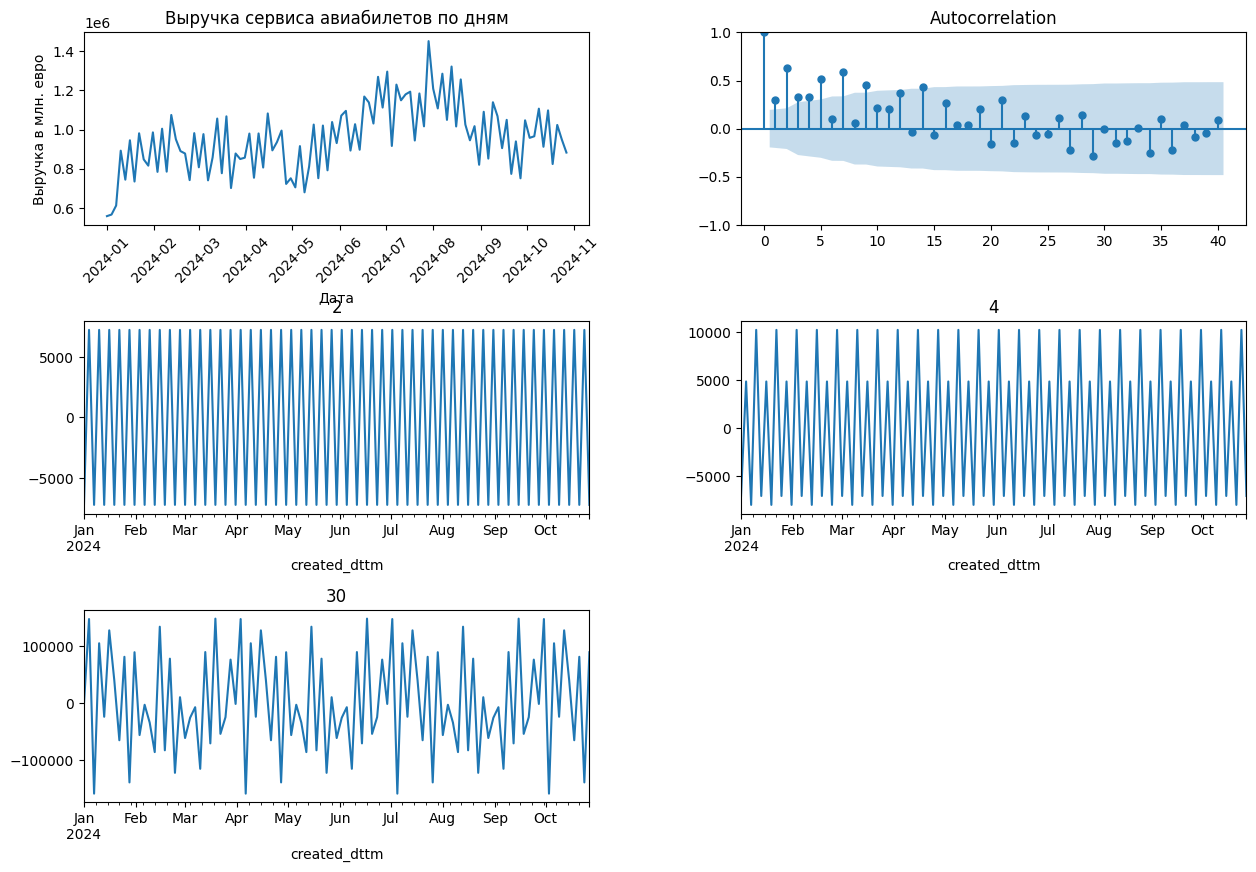

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot (3,2,1)
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.plot(df_AIR.index, df_AIR.values)
plt.title("Выручка сервиса авиабилетов по дням")
plt.xlabel('Дата')
plt.ylabel('Выручка в млн. евро')
plt.xticks(rotation=45)
plt.subplot(3, 2, 2)
plot_acf(df_AIR, lags=40, ax=plt.gca())

seasonal_periods = [2, 4, 30]

for i, period in enumerate(seasonal_periods, start=3):
  if len(df_AIR)>= 2*period:
    plt.subplot (3,2,i)
    decomposition = seasonal_decompose(df_AIR, model='additive', period=period)
    decomposition.seasonal.plot(ax=plt.gca(), title = period)
plt.show()

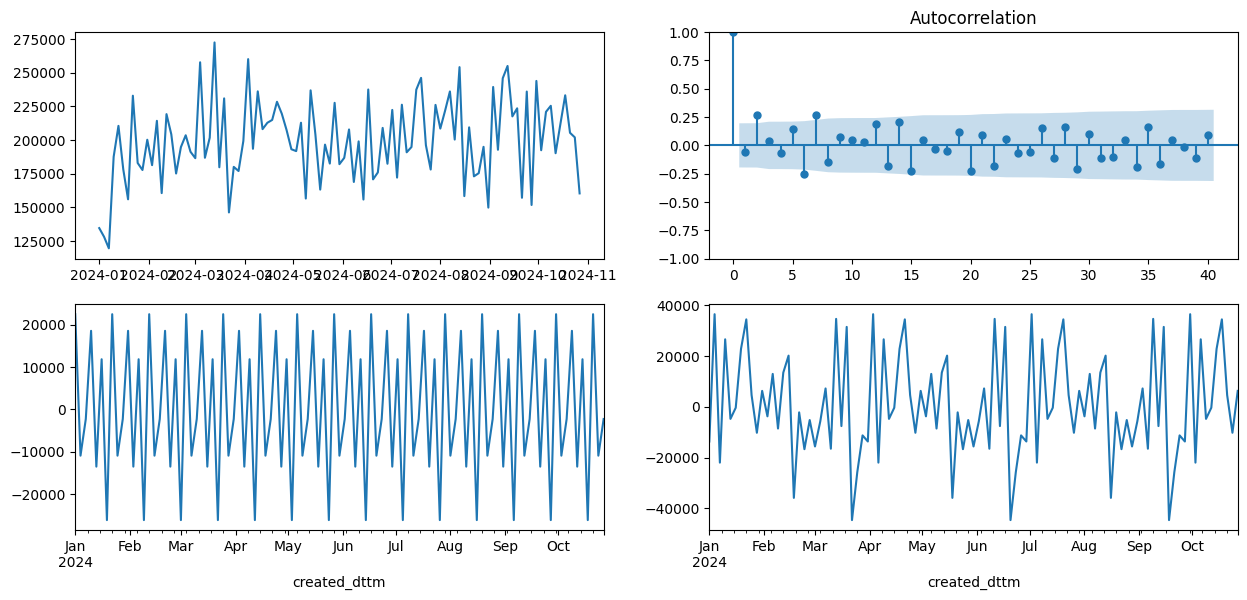

In [ ]:
plt.figure(figsize=(15,10))
plt.subplot (3,2,1)
plt.plot(df_HOT.index, df_HOT.values)
plt.subplot(3, 2, 2)
plot_acf(df_HOT, lags=40, ax=plt.gca())

seasonal_periods = [7, 30, 90]

for i, period in enumerate(seasonal_periods, start=3):
  if len(df_HOT)>= 2*period:
    plt.subplot (3,2,i)
    decomposition = seasonal_decompose(df_HOT, model='additive', period=period)
    decomposition.seasonal.plot(ax=plt.gca())
plt.show()

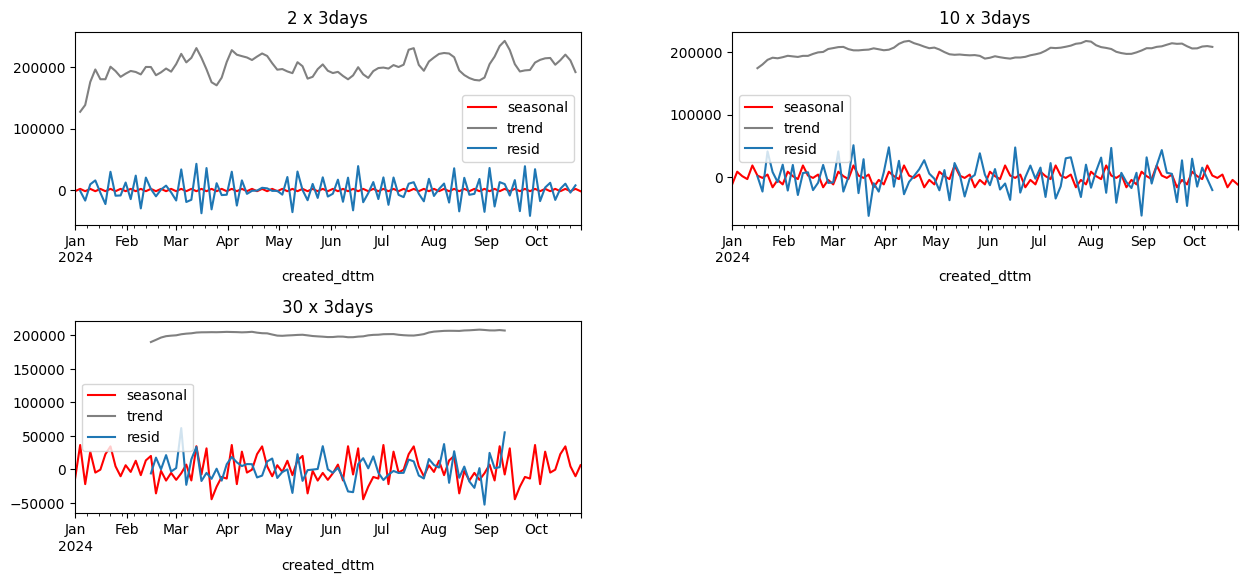

In [ ]:
"""
plt.figure(figsize=(15,10))
plt.subplot (3,2,1)
plt.plot(df_HOT.index, df_HOT.values)
plt.subplot(3, 2, 2)
plot_acf(df_HOT, lags=40, ax=plt.gca())
"""

# есть выявленной сезонности --> используем аддитивную модель

seasonal_periods = [2, 10, 30]
plt.figure(figsize=(15,10))
for i, period in enumerate(seasonal_periods, start=3):
  if len(df_HOT)>= 2*period:
    plt.subplot (3,2,i)
    plt.title(f"{period} x 3days")
    plt.xlabel("")
    plt.ylabel("")
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    decomposition = seasonal_decompose(df_HOT, model='additive', period=period)
    decomposition.seasonal.plot(ax=plt.gca(), color="red")
    decomposition.trend.plot(ax=plt.gca(), color="grey")
    decomposition.resid.plot(ax=plt.gca())
    plt.legend()
plt.show()

# decomposition.trend.plot()
# decomposition.resid

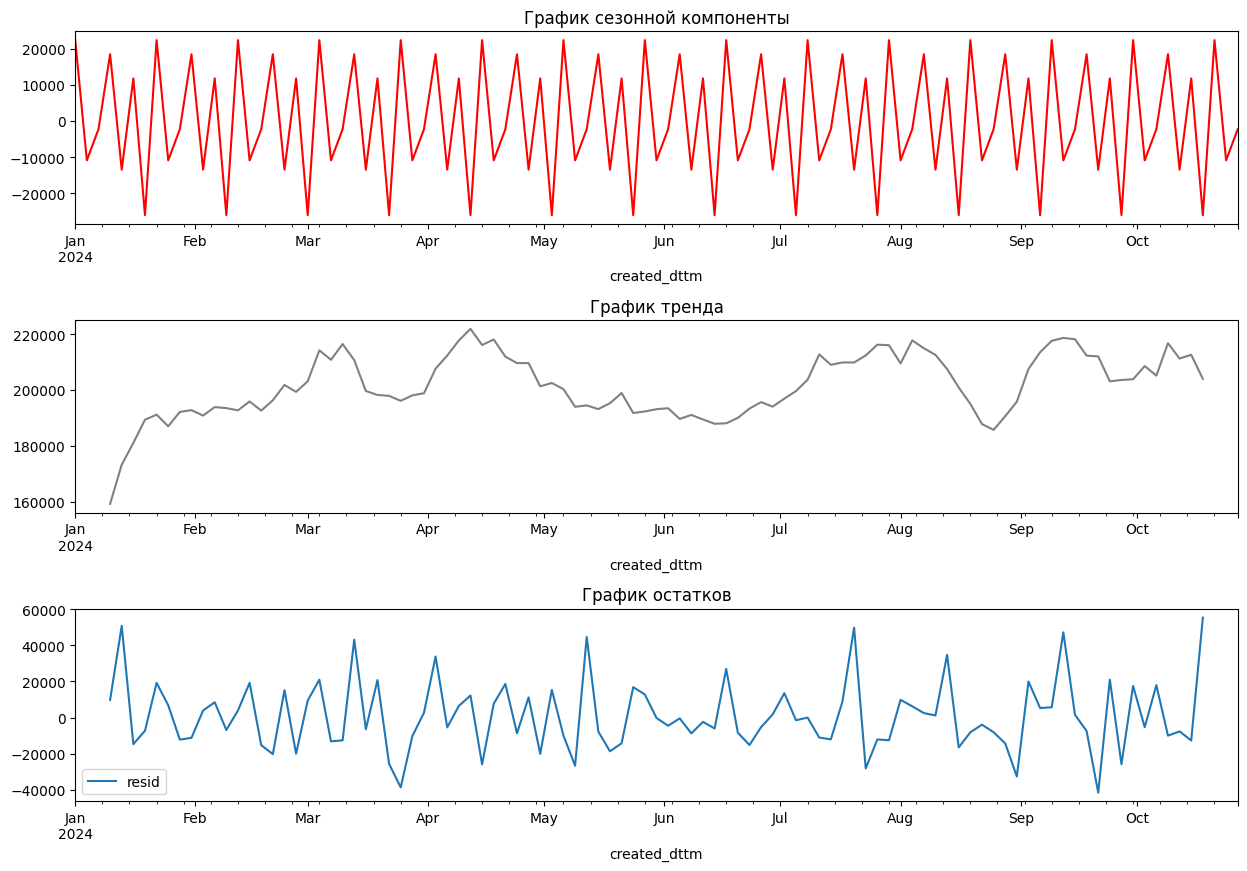

In [ ]:
plt.figure(figsize=(15,10))
period = 7
plt.subplot (3,1,1)
plt.title(f"График сезонной компоненты")
plt.xlabel("")
plt.ylabel("")
plt.subplots_adjust(wspace=0.3, hspace=0.5)
decomposition = seasonal_decompose(df_HOT, model='additive', period=period)
decomposition.seasonal.plot(ax=plt.gca(), color="red")
plt.subplot (3,1,2)
plt.title(f"График тренда")
plt.xlabel("")
plt.ylabel("")
plt.subplots_adjust(wspace=0.3, hspace=0.5)
decomposition.trend.plot(ax=plt.gca(), color="grey")
plt.subplot (3,1,3)
plt.title(f"График остатков")
plt.xlabel("")
plt.ylabel("")
plt.subplots_adjust(wspace=0.3, hspace=0.5)
decomposition.resid.plot(ax=plt.gca())
plt.legend()
plt.show()


4. Проверка на стационарность и стационаризация
 Определите тип колеблемости с помощью автокорреляции первого порядка по отклонению от тренда.
 Определите стационарность набора данных с помощью теста Дики-Фуллера (ADF). Если p-value > 0.05, ряд нестационарен.
 Примените первое дифференцирование: df_diff = df.diff().dropna(), если ряд нестационарен.
 Повторно провести ADF-тест для df_diff. Если ряд все еще нестационарен, применить второе дифференцирование. Порядок дифференцирования d = 1 (реже 2).



### Работаем только с отелями

In [ ]:
p_values= adfuller(df_HOT.values)[1]
print(p_values)

0.00041223520111176694


In [ ]:
values = df_HOT
lb_test = acorr_ljungbox(values, lags=10) # проверка на автокорреляцию
print(lb_test)
# тест проверяет на отсутствие автокорреляции
# см. только на значение последнего лага
# если pvalue последнего лага > 0.05 - автокорреляции НЕТ

# [!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!]

      lb_stat  lb_pvalue
1    0.386102   0.534356
2    7.833960   0.019901
3    7.958954   0.046868
4    8.497410   0.074966
5   10.823533   0.054993
6   17.857988   0.006597
7   25.900816   0.000525
8   28.209354   0.000436
9   28.837244   0.000690
10  29.083428   0.001208


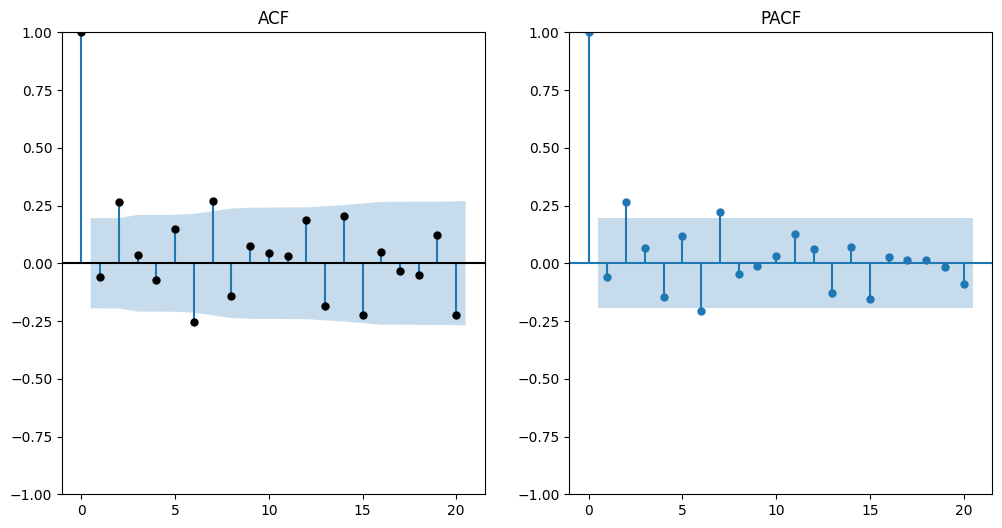

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_acf(df_HOT, ax=plt.gca(), lags=20, color="black")
plt.title('ACF')

plt.subplot(122) #расположение 1 - колво строк 2 - столбцов 3 -  позиция(индекс) (122)
plot_pacf(df_HOT, ax=plt.gca(), lags=20)
plt.title('PACF')

plt.show()

# Ряд описывается моделью ARIMA(p,0,q) с p,q > 0;
# по структуре ACF/PACF предпочтительна ARMA-модель умеренного порядка (2–3).

# билеты - ARIMA
# отели - ARMA

In [ ]:
train_size = int(len(df_HOT)*0.7) # размер тестовой группы
trainh = df_HOT[:train_size] # 70%
testh = df_HOT[train_size:] # 30%

#model_hot = ARIMA(trainh, order = (0,0,0))
#model_hot_fit = model_hot.fit()

In [ ]:
model_hot2 = ARIMA(trainh, order = (7, 0, 7)) # 8, 0, 8 все P>|z| незначимы
model_hot_fit2 = model_hot2.fit()

print(model_hot_fit2.summary())

                               SARIMAX Results                                
Dep. Variable:            revenue_eur   No. Observations:                   70
Model:                 ARIMA(7, 0, 7)   Log Likelihood                -806.275
Date:                Mon, 22 Dec 2025   AIC                           1644.550
Time:                        14:07:43   BIC                           1680.526
Sample:                    01-01-2024   HQIC                          1658.840
                         - 07-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.965e+05   1.05e+04     18.630      0.000    1.76e+05    2.17e+05
ar.L1         -0.4416      0.167     -2.649      0.008      -0.768      -0.115
ar.L2         -0.6117      0.195     -3.137      0.0

In [ ]:
# брутфорс всех p, q

for p in range(1, 5):
    for q in range(1, 5):
          model = ARIMA(trainh, order=(p, 0, q))
          res = model.fit()

          aic = res.aic
          bic = res.bic

          lb_p = acorr_ljungbox(
              res.resid,
              lags=[10],
              return_df=True
          )["lb_pvalue"].iloc[0]

          # значимость коэффициентов
          pvals = res.pvalues
          nonsig = pvals[pvals > 0.05].index.tolist()

          print(
              f"ARIMA({p},0,{q}) | "
              f"AIC={aic:.1f} | "
              f"BIC={bic:.1f} | "
              f"LB p-value={lb_p:.3f} | "
              f"незначимые: {nonsig}"
          )

ARIMA(1,0,1) | AIC=1649.7 | BIC=1658.7 | LB p-value=0.070 | незначимые: []
ARIMA(1,0,2) | AIC=1649.3 | BIC=1660.5 | LB p-value=0.425 | незначимые: []
ARIMA(1,0,3) | AIC=1646.5 | BIC=1660.0 | LB p-value=0.843 | незначимые: ['ma.L2']
ARIMA(1,0,4) | AIC=1647.8 | BIC=1663.5 | LB p-value=0.824 | незначимые: ['ma.L2', 'ma.L4']
ARIMA(2,0,1) | AIC=1649.3 | BIC=1660.6 | LB p-value=0.421 | незначимые: ['ar.L2']
ARIMA(2,0,2) | AIC=1651.3 | BIC=1664.8 | LB p-value=0.430 | незначимые: ['ar.L1', 'ar.L2', 'ma.L1', 'ma.L2']
ARIMA(2,0,3) | AIC=1648.7 | BIC=1664.5 | LB p-value=0.817 | незначимые: ['ar.L1', 'ar.L2', 'ma.L2']
ARIMA(2,0,4) | AIC=1649.4 | BIC=1667.4 | LB p-value=0.788 | незначимые: ['ar.L1', 'ma.L1', 'ma.L4']
ARIMA(3,0,1) | AIC=1641.7 | BIC=1655.2 | LB p-value=0.898 | незначимые: []
ARIMA(3,0,2) | AIC=1637.8 | BIC=1653.5 | LB p-value=0.965 | незначимые: []
ARIMA(3,0,3) | AIC=1638.4 | BIC=1656.4 | LB p-value=0.956 | незначимые: ['ma.L2']
ARIMA(3,0,4) | AIC=1648.3 | BIC=1668.6 | LB p-value=0.

In [ ]:
# --> 2, 0, 2

# На основании анализа ACF/PACF и перебора моделей ARIMA(p,0,q) была выбрана модель ARIMA(3,0,2)
# Она обеспечивает минимальные значения AIC/BIC, отсутствие автокорреляции остатков (тест Льюнга–Бокса) и статистическую значимость всех параметров.

# [!] По графику: ARIMA (2, 0, 2)

hot_model = ARIMA(trainh, order=(2, 0, 2))
hot_fit = hot_model.fit()

forecast = hot_fit.forecast(steps=len(testh))
forecast_index = testh.index

mse = mean_squared_error(testh, forecast) # дисперсия
rmse = np.sqrt(mse) # стандартное отклонение
# если rmse превышает 20% от среднего значения, то модель не оч

mae = mean_absolute_error(testh, forecast) # посчитали критерий САО

mape = np.mean(np.abs((testh-forecast)/testh*100))
# показывает, на сколько % в среднем ошибается модель
# хороший mape меньше 10%

print(f"RMSE: {rmse:.2f},\t avg: {np.mean(df_HOT):.2f}\t (RMSE = {rmse/np.mean(df_HOT)*100:.2f}%) \nMAE (CAO): {mae:.2f} \nExceptions: {mape:.2f}%")

# Модель ARIMA(3,0,2) обеспечивает RMSE ≈ 16% от среднего уровня ряда и MAPE ≈ 13.8%,
# это свидетельствует об удовлетворительном качестве прогноза при использовании исключительно авторегрессионной структуры.

RMSE: 31955.19,	 avg: 199643.31	 (RMSE = 16.01%) 
MAE (CAO): 27219.86 
Exceptions: 13.33%


      lb_stat  lb_pvalue
1    0.011356   0.915136
2    0.149960   0.927762
3    0.305123   0.959062
4    1.229804   0.873168
5    1.495957   0.913536
6    3.873600   0.693777
7    8.804057   0.267032
8   10.009396   0.264367
9   10.113050   0.341411
10  10.121792   0.429874


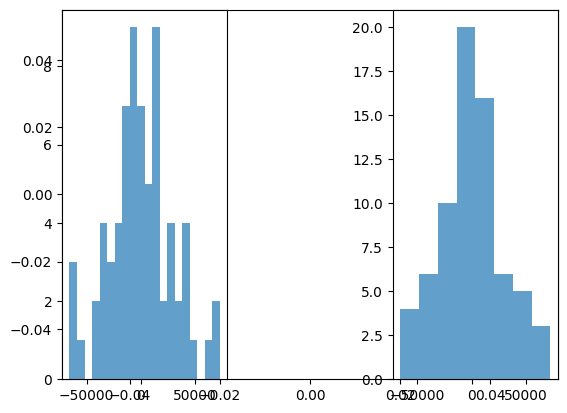

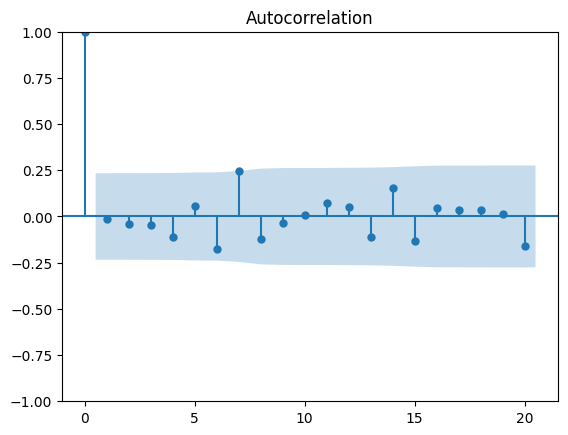

In [ ]:
# проверка остатков на нормальность и автокорреляцию

residuals = hot_fit.resid
lb_test = acorr_ljungbox(residuals, lags=10) # проверка на автокорреляцию
print(lb_test)
# pvalue последнего лага > 0.05 - автокорреляции НЕТ

plt.plot()
plt.subplots_adjust(wspace=1, hspace=0.5)
plt.subplot(121)
plt.hist(residuals, bins = 20, alpha = 0.7)
# нет нормальности распределения

plt.subplot(122)
plt.hist(residuals, bins = 'sturges', alpha = 0.7)
plt.show()
# как бы близко к нормальности распределения

#plt.subplot(123)
plot_acf(residuals, lags=20)
plt.show()
# нет значимых лагов, следовательно автокорреляции тоже нет

In [ ]:
# применяем модель ко всем данным, без дележки

final_model = ARIMA(df_HOT, order=(2, 0, 2))
final_model_fit = final_model.fit()

future_step = 10
future_forecast = final_model_fit.forecast(steps=future_step)

future_forecast

,predicted_mean
2024-10-30,199821.094886
2024-11-02,189040.153392
2024-11-05,194388.266284
2024-11-08,203954.086477
2024-11-11,205132.011594
2024-11-14,199515.728568
2024-11-17,196031.265805
2024-11-20,197974.812850
2024-11-23,201170.768274
2024-11-26,201462.937165


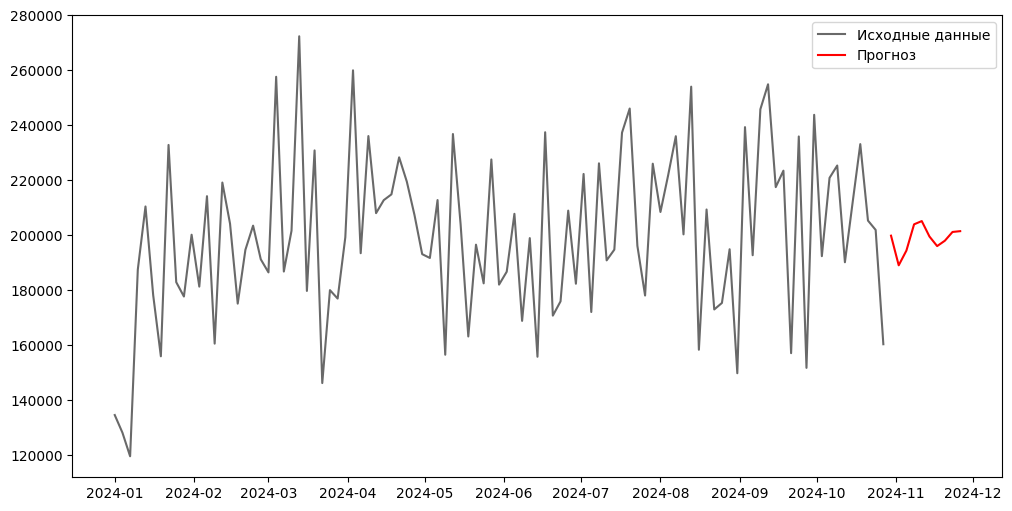

In [ ]:
plt.figure(figsize = (12, 6))
plt.plot(df_HOT.index, df_HOT.values, label='Исходные данные', color='dimgray')
plt.plot(future_forecast.index, future_forecast, label='Прогноз', color='red')
plt.legend()

plt.show()

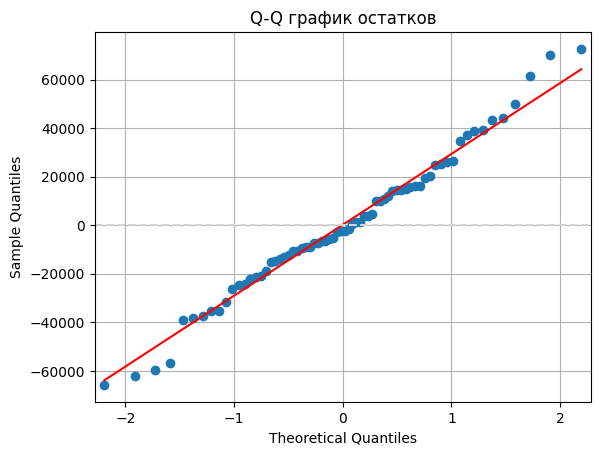

ShapiroResult(statistic=np.float64(0.985709342190854), pvalue=np.float64(0.6098513515640412))


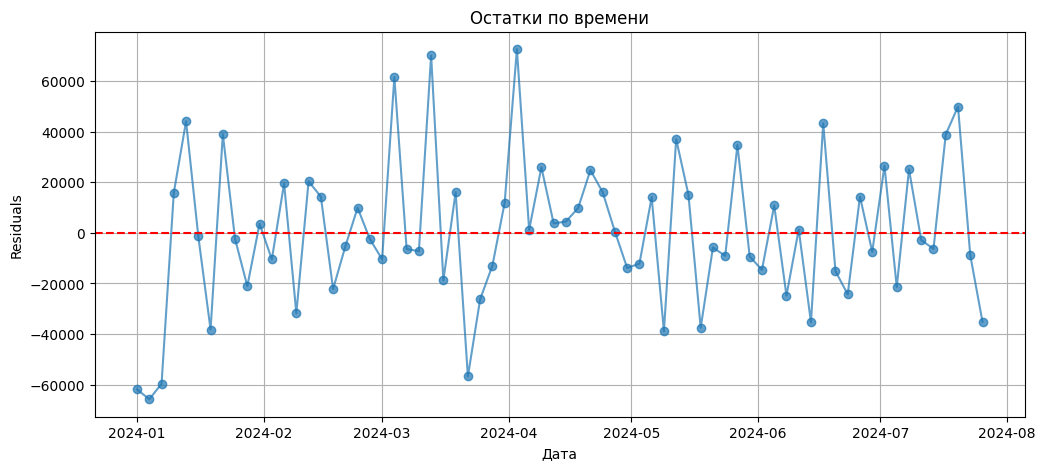

In [ ]:
# по sarima: qq-plot, тест шапиро, проверка гомоскедастичности

sm.qqplot(residuals, line='s')
plt.title('Q-Q график остатков')
plt.axhline(0, color='lightgrey', linestyle='--')
plt.grid()
plt.show()

print(shapiro(residuals)) # > 0,05 --> остатки нормальны

plt.figure(figsize=(12,5))
plt.plot(residuals.index, residuals, marker='o', linestyle='-', alpha=0.7)
plt.title('Остатки по времени')
plt.xlabel('Дата')
plt.ylabel('Residuals')
plt.grid()
plt.axhline(0, color='red', linestyle='--')
plt.show()

### Работаем только с авиабилетами

In [ ]:
p_values= adfuller(df_AIR.values)[1]
print(p_values)

0.4637838431270917


In [ ]:
df_AIRd = df_AIR.diff().dropna()
p_v= adfuller(df_AIRd.values)[1]
print(p_v)

0.00014985478786491393


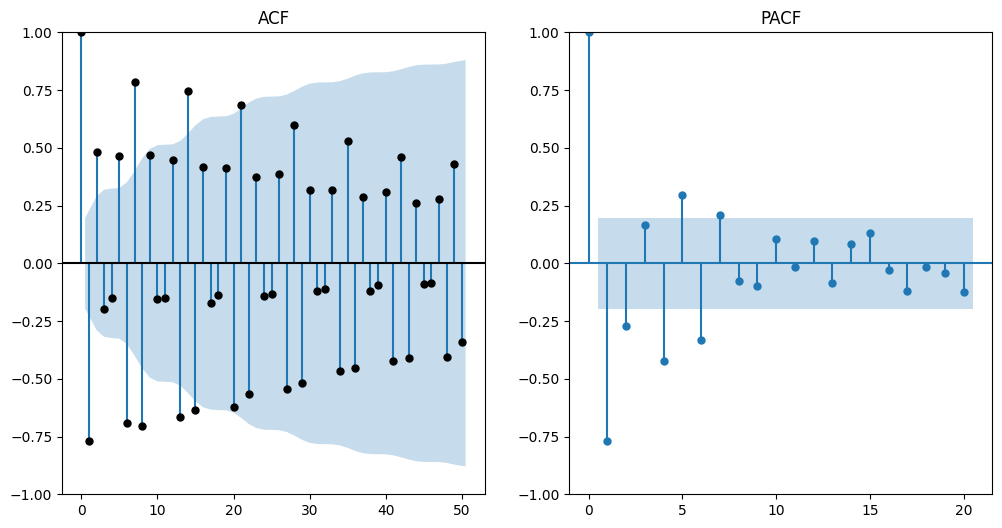

'\nПочему ACF «медленно затухает до 50 лага»\nПричина не в скрытой сезонности, а в комбинации факторов:\nОдин год данных\nЛокальный тренд + пик\nДвойное обычное дифференцирование\nВысокий шум\n\nВ результате:\nACF теряет интерпретируемость,\nдоверительный интервал раздувается,\n«последний значащий лаг» перестаёт иметь смысл.\n'

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_acf(df_AIRd, ax=plt.gca(), lags=50, color="black")
plt.title('ACF')

plt.subplot(122) #расположение 1 - колво строк 2 - столбцов 3 -  позиция(индекс) (122)
plot_pacf(df_AIRd, ax=plt.gca(), lags=20)
plt.title('PACF')

plt.show()

# несезонный ряд с трендом и структурным пиком
# ACF не обрывается
"""
Почему ACF «медленно затухает до 50 лага»
Причина не в скрытой сезонности, а в комбинации факторов:
Один год данных
Локальный тренд + пик
Двойное обычное дифференцирование
Высокий шум

В результате:
ACF теряет интерпретируемость,
доверительный интервал раздувается,
«последний значащий лаг» перестаёт иметь смысл.
"""

In [ ]:
train_size = int(len(df_AIR)*0.7) # размер тестовой группы
traina = df_HOT[:train_size] # 70%
testa = df_HOT[train_size:] # 30%

In [ ]:
# брутфорс всех p, q

for p in [1, 4, 6, 7]:
    q = 1 # model MA
    model = ARIMA(traina, order=(p, 1, q))
    res = model.fit()

    aic = res.aic
    bic = res.bic

    lb_p = acorr_ljungbox(
        res.resid,
        lags=[10],
        return_df=True
    )["lb_pvalue"].iloc[0]

    # значимость коэффициентов
    pvals = res.pvalues
    nonsig = pvals[pvals > 0.05].index.tolist()

    print(
        f"ARIMA({p},1,{q}) | "
        f"AIC={aic:.1f} | "
        f"BIC={bic:.1f} | "
        f"LB p-value={lb_p:.3f} | "
        f"незначимые: {nonsig}"
      )

ARIMA(1,1,1) | AIC=1636.8 | BIC=1643.5 | LB p-value=0.123 | незначимые: []
ARIMA(4,1,1) | AIC=1641.6 | BIC=1655.0 | LB p-value=0.146 | незначимые: ['ar.L1', 'ar.L2', 'ar.L3', 'ar.L4', 'ma.L1']
ARIMA(6,1,1) | AIC=1627.2 | BIC=1645.1 | LB p-value=0.923 | незначимые: ['ar.L3', 'ar.L4', 'ar.L5']
ARIMA(7,1,1) | AIC=1630.3 | BIC=1650.4 | LB p-value=0.939 | незначимые: ['ar.L1', 'ar.L2', 'ar.L3', 'ar.L4', 'ar.L5', 'ar.L6', 'ar.L7', 'ma.L1']


In [ ]:
for p in [1, 4, 6, 7]:
    q = 1 # model MA
    model = ARIMA(traina, order=(p, 1, q))
    res = model.fit()
    print(res.summary())

                               SARIMAX Results                                
Dep. Variable:            revenue_eur   No. Observations:                   70
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -815.406
Date:                Mon, 22 Dec 2025   AIC                           1636.812
Time:                        14:07:50   BIC                           1643.514
Sample:                    01-01-2024   HQIC                          1639.471
                         - 07-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2984      0.124     -2.402      0.016      -0.542      -0.055
ma.L1         -0.4814      0.117     -4.101      0.000      -0.711      -0.251
sigma2      8.382e+08   3.22e-11    2.6e+19      0.0

In [ ]:
for param in [1, 4, 6, 7]:

  print(f"Модель ARIMA({param}, 1, 1)\nПрогноз:", end='\t')

  air_model = ARIMA(traina, order=(param, 1, 1))
  air_fit = air_model.fit()

  forecasta = air_fit.forecast(steps=len(testa))
  for i in forecasta.values.tolist()[:5]:
    print(f"{i:.2f}", end='\t')
  print()
  forecasta_index = testa.index

  mse = mean_squared_error(testa, forecasta) # дисперсия
  rmse = np.sqrt(mse) # стандартное отклонение

  mae = mean_absolute_error(testa, forecasta) # посчитали критерий САО

  mape = np.mean(np.abs((testa-forecast)/testa*100))

  print(f"RMSE: {rmse:.2f},\t avg: {np.mean(df_HOT):.2f}\t (RMSE = {rmse/np.mean(df_HOT)*100:.2f}%) \nMAE (CAO): {mae:.2f} \nExceptions: {mape:.2f}%", end='\n\n')


Модель ARIMA(1, 1, 1)
Прогноз:	205789.61	197510.67	199981.27	199243.99	199464.01	
RMSE: 31195.63,	 avg: 199643.31	 (RMSE = 15.63%) 
MAE (CAO): 26444.64 
Exceptions: 13.33%

Модель ARIMA(4, 1, 1)
Прогноз:	210483.68	191565.67	194597.11	198899.75	194464.22	
RMSE: 31969.16,	 avg: 199643.31	 (RMSE = 16.01%) 
MAE (CAO): 27280.81 
Exceptions: 13.33%

Модель ARIMA(6, 1, 1)
Прогноз:	229094.26	180168.43	190952.69	209923.71	202326.45	
RMSE: 30328.04,	 avg: 199643.31	 (RMSE = 15.19%) 
MAE (CAO): 25151.16 
Exceptions: 13.33%

Модель ARIMA(7, 1, 1)
Прогноз:	221551.95	183889.70	187065.36	213600.42	205252.58	
RMSE: 31329.71,	 avg: 199643.31	 (RMSE = 15.69%) 
MAE (CAO): 25869.67 
Exceptions: 13.33%



	 ARIMA (4, 1, 1)	


      lb_stat  lb_pvalue
1    0.276346   0.599106
2    0.471007   0.790173
3    1.126683   0.770637
4    1.263981   0.867456
5    1.361336   0.928496
6    4.046700   0.670356
7   12.226469   0.093353
8   14.210153   0.076450
9   14.623467   0.101812
10  14.624053   0.146381


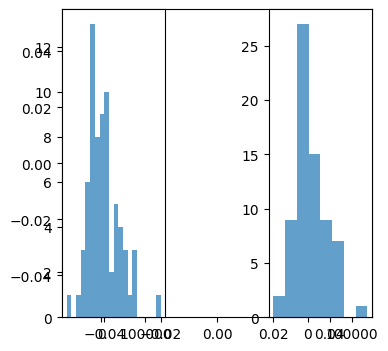

<Figure size 300x300 with 0 Axes>

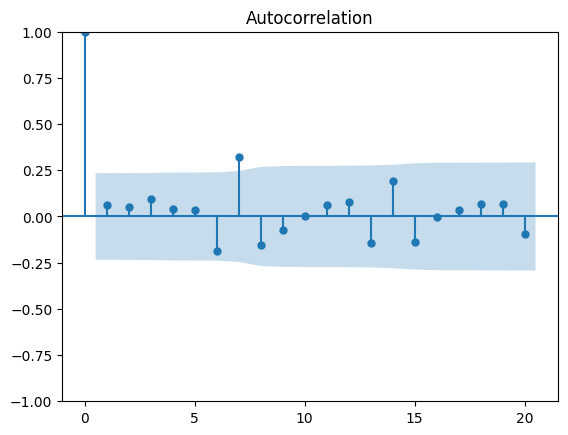

In [ ]:
# проверка остатков на нормальность и автокорреляцию
air_model = ARIMA(traina, order=(4, 1, 1))
air_fit = air_model.fit()

print("\t ARIMA (4, 1, 1)\t\n\n")

residuals = air_fit.resid
lb_test = acorr_ljungbox(residuals, lags=10) # проверка на автокорреляцию
print(lb_test)
# pvalue последнего лага > 0.05 - автокорреляции НЕТ

plt.figure(figsize=(4,4))
plt.plot()
plt.subplots_adjust(wspace=1, hspace=0.5)
plt.subplot(121)
plt.hist(residuals, bins = 20, alpha = 0.7)
# как бы близко к нормальности распределения

plt.subplot(122)
plt.hist(residuals, bins = 'sturges', alpha = 0.7)
plt.show()
# как бы близко к нормальности распределения

#plt.subplot(123)
plt.figure(figsize=(3,3))
plot_acf(residuals, lags=20)
plt.show()
# нет значимых лагов, следовательно автокорреляции тоже нет

2649.2495772298744
2657.065087787839
5.150181652846645e-05


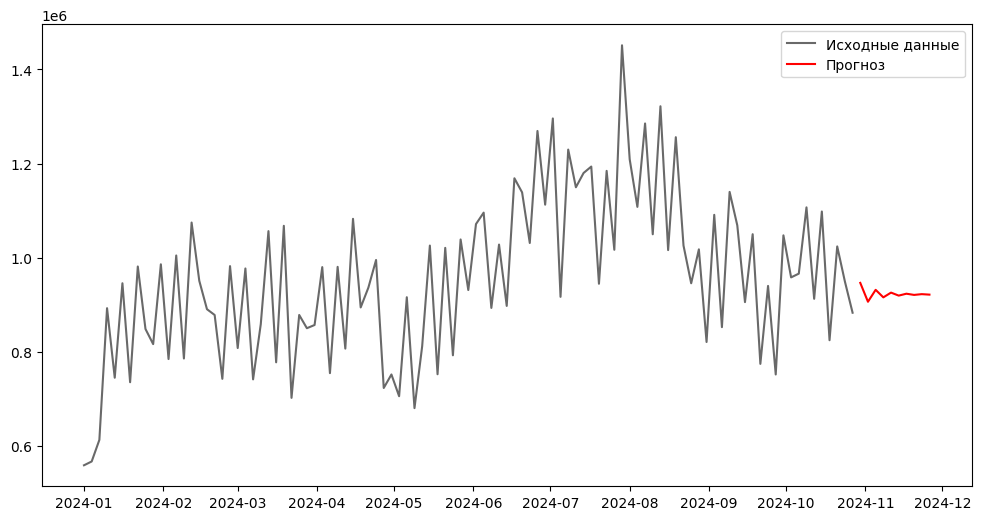

In [ ]:
final_model = ARIMA(df_AIR, order=(1, 1, 1))
final_model_fit = final_model.fit()

future_step = 10
future_forecasta = final_model_fit.forecast(steps=future_step)

print(final_model_fit.aic)
print(final_model_fit.bic)
print(acorr_ljungbox(
        final_model_fit.resid,
        lags=[10],
        return_df=True
    )["lb_pvalue"].iloc[0])

plt.figure(figsize = (12, 6))
plt.plot(df_AIR.index, df_AIR.values, label='Исходные данные', color='dimgray')
plt.plot(future_forecasta.index, future_forecasta, label='Прогноз', color='red')
plt.legend()
plt.show()

2606.105198300623
2621.7362194165516
0.06403677897139125


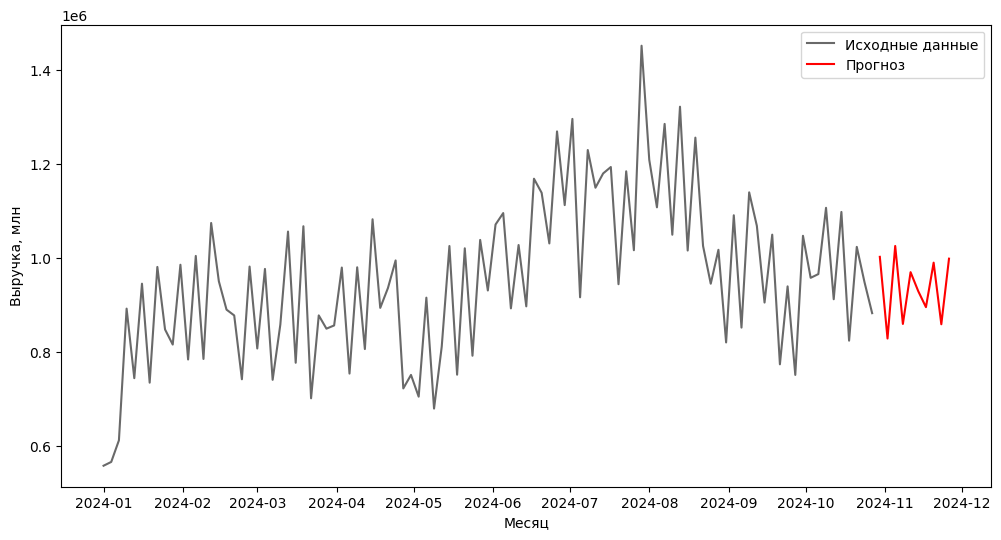

In [ ]:
final_model = ARIMA(df_AIR, order=(4, 1, 1))
final_model_fit = final_model.fit()

future_step = 10
future_forecasta = final_model_fit.forecast(steps=future_step)

print(final_model_fit.aic)
print(final_model_fit.bic)
print(acorr_ljungbox(
        final_model_fit.resid,
        lags=[10],
        return_df=True
    )["lb_pvalue"].iloc[0])

plt.figure(figsize = (12, 6))
plt.plot(df_AIR.index, df_AIR.values, label='Исходные данные', color='dimgray')
plt.plot(future_forecasta.index, future_forecasta, label='Прогноз', color='red')
plt.xlabel('Месяц')
plt.ylabel('Выручка, млн')
plt.legend()
plt.show()

2599.0364126957497
2619.8777741836543
0.26533759401053214


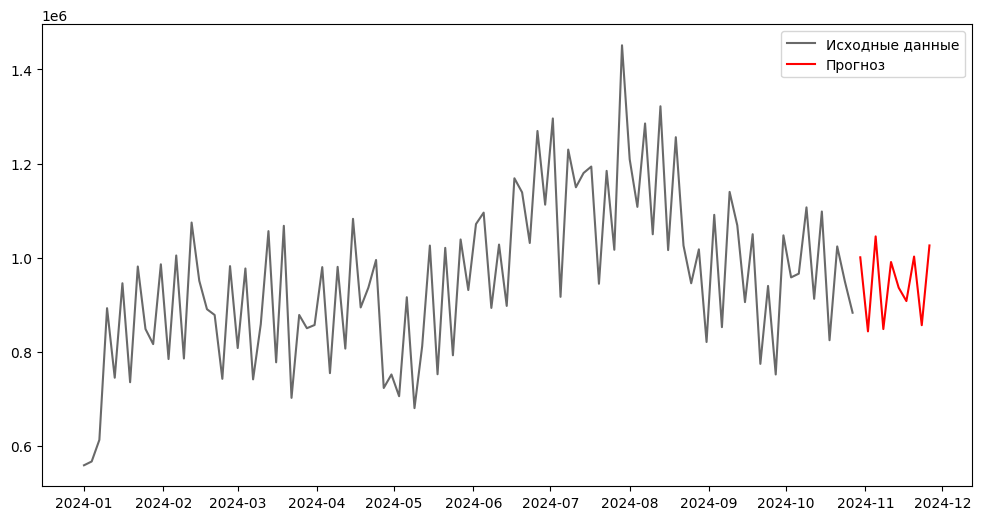

In [ ]:
final_model = ARIMA(df_AIR, order=(6, 1, 1))
final_model_fit = final_model.fit()

future_step = 10
future_forecasta = final_model_fit.forecast(steps=future_step)

print(final_model_fit.aic)
print(final_model_fit.bic)
print(acorr_ljungbox(
        final_model_fit.resid,
        lags=[10],
        return_df=True
    )["lb_pvalue"].iloc[0])

plt.figure(figsize = (12, 6))
plt.plot(df_AIR.index, df_AIR.values, label='Исходные данные', color='dimgray')
plt.plot(future_forecasta.index, future_forecasta, label='Прогноз', color='red')
plt.legend()
plt.show()

2596.9647443234903
2620.411275997383
0.40693066129386424


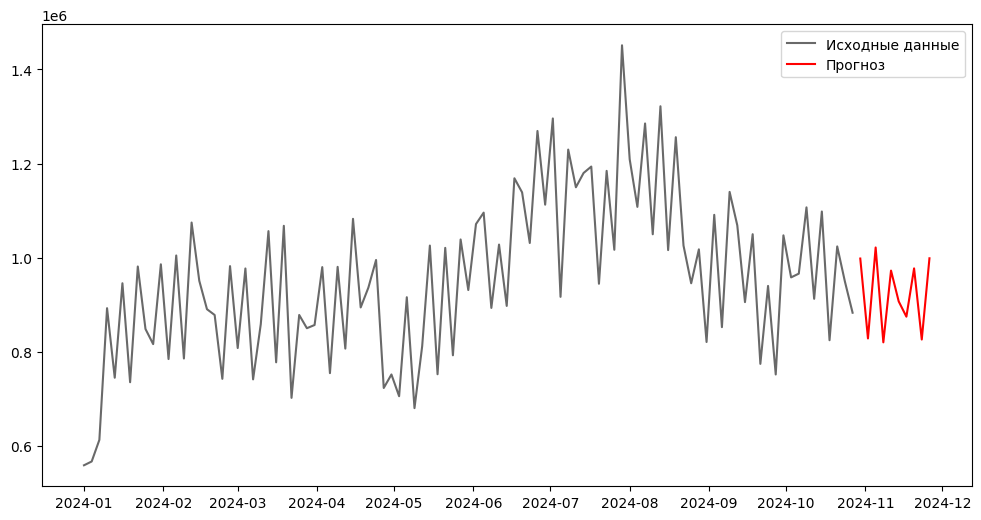

In [ ]:
final_model = ARIMA(df_AIR, order=(7, 1, 1))
final_model_fit = final_model.fit()

future_step = 10
future_forecasta = final_model_fit.forecast(steps=future_step)

print(final_model_fit.aic)
print(final_model_fit.bic)
print(acorr_ljungbox(
        final_model_fit.resid,
        lags=[10],
        return_df=True
    )["lb_pvalue"].iloc[0])

plt.figure(figsize = (12, 6))
plt.plot(df_AIR.index, df_AIR.values, label='Исходные данные', color='dimgray')
plt.plot(future_forecasta.index, future_forecasta, label='Прогноз', color='red')
plt.legend()
plt.show()